# Practical 01 &mdash; Four classifiers, one real table

**Who earns more than \$50K a year?** The question comes from the 1994 US census: 48,842 people,
each described by age, education, occupation, hours worked and a few more columns, and labeled with
whether their income was above \$50,000. It is a real table with real problems &mdash; missing
values, a column that is not what it seems, a test file in a slightly different format &mdash; and
it is small enough to study on a laptop.

We put the four classifier families of the course side by side on it:

| family | how it decides | what it assumes | lecture | what we tune |
|---|---|---|---|---|
| **logistic regression** | a weighted sum of the features, squashed by a sigmoid | the log-odds are linear in the features | 04 | `C` |
| **naive Bayes** (generative) | Bayes' rule: how typical is this profile of each class? | features are independent *given the class* | 05 | how numbers are modeled |
| **support vector machine** | the widest margin, with a linear or an RBF kernel | a wide margin separates the classes (in the kernel's feature space); no probability model | 06&ndash;07 | kernel, `C`, $\gamma$ |
| **decision tree** | a sequence of yes/no questions on one feature at a time | the answer is constant inside axis-aligned boxes | 08 | `min_samples_leaf` |

**The use case.** Picture a fundraising campaign that can contact only part of a long list and wants
to reach people with higher incomes first. It needs two things from a model, and we measure both:

1. a good **ranking** of people by their chance of earning >\$50K. This is measured by the **ROC
   AUC**, which every model can produce and which needs no threshold. **Models are chosen by AUC.**
2. a **yes/no flag**, measured by **accuracy**. Where to cut the ranking is a *separate* decision,
   made after the model is chosen and on training data only (&sect;7).

**Rules of the game.**
* The test file's labels never choose anything. Models, settings and thresholds are all chosen
  before &sect;7, on training rows only; from &sect;7 on, the test file only reports and analyzes.
* Everything learned from data &mdash; category lists, means and standard deviations,
  hyperparameters, thresholds &mdash; is learned from the training part of each split. We write
  these loops **by hand** (no `Pipeline`, no `GridSearchCV`) so that you can see exactly where test
  information could leak in.
* No conclusion rests on one split: scores come with their spread.

> &#11088; **Key idea.** On real tabular data the winner is decided by the data &mdash; how much of
> it there is, what is in it, and what you need the predictions for &mdash; not by the algorithm's
> reputation. Accuracy is only one of several things worth comparing.

> &#128161; **Before you run anything:** which family do you expect to win? Write it down. &sect;7
> and &sect;8 will tell you.

*The first run downloads 0.6 MB from the UCI repository and caches it in `data/raw/`. Run each cell
with Shift+Enter; the whole notebook takes two to five minutes on a laptop, most of it spent on
the kernel SVM and on the learning curves of &sect;8.*

In [1]:
import hashlib, io, sys, time, urllib.request, warnings, zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.special import logit, logsumexp
from scipy.stats import rankdata

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import KBinsDiscretizer, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import CategoricalNB, GaussianNB
from sklearn.svm import SVC, LinearSVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, log_loss, roc_auc_score, roc_curve
from sklearn.exceptions import ConvergenceWarning

HERE = Path.cwd()                                   # Jupyter runs a notebook from its own folder
assert (HERE.parent / "nb_utils.py").exists(), "open this notebook from notebooks/practical/"
sys.path.insert(0, str(HERE.parent))                # the course's nb_utils.py lives one folder up
from nb_utils import use_style

use_style("notes")
C0, C1, CG, CN = "#0072B2", "#D55E00", "#009E73", "#E69F00"
CP, CX = "#CC79A7", "0.62"                          # a fifth color; gray for baselines
mpl.rcParams["axes.prop_cycle"] = mpl.cycler(color=[C0, C1, CG, CN, CP])   # frozen palette
COLORS = {"logistic regression": C0, "naive Bayes": CN, "linear SVM": CG, "RBF SVM": CP,
          "decision tree": C1}

SEED = 0                  # <-- CHANGE ME: another seed draws other development rows and folds
N_TRAIN = 5_000           # <-- CHANGE ME: training rows for sections 2-7 (try 2_000 or 10_000)
T_START = time.perf_counter()
print("ready")

ready


## 1. The data, and its quirks

The data is the UCI **Adult** dataset (Becker &amp; Kohavi, 1996; license CC BY 4.0,
doi:[10.24432/C5XW20](https://doi.org/10.24432/C5XW20)). The next cell downloads the archive once,
keeps the two files we need in `data/raw/adult/`, and checks them against known SHA-256
fingerprints, so that everybody works on exactly the same bytes. *Offline?* Download the zip by hand
and put `adult.data` and `adult.test` in that folder.

In [2]:
URL = "https://archive.ics.uci.edu/static/public/2/adult.zip"
RAW = HERE / "data" / "raw" / "adult"               # git-ignored; filled on the first run
SHA256 = {"adult.data": "5b00264637dbfec36bdeaab5676b0b309ff9eb788d63554ca0a249491c86603d",
          "adult.test": "a2a9044bc167a35b2361efbabec64e89d69ce82d9790d2980119aac5fd7e9c05"}

def check(name, content):
    if hashlib.sha256(content).hexdigest() != SHA256[name]:
        raise RuntimeError(f"{name} is not the expected file: delete {RAW} and run again, "
                           f"or download {URL} by hand and unzip it there")
    return content


if not all((RAW / name).exists() for name in SHA256):
    try:
        request = urllib.request.Request(URL, headers={"User-Agent": "teaching-notebook"})
        with urllib.request.urlopen(request, timeout=60) as response:
            archive = zipfile.ZipFile(io.BytesIO(response.read()))
        files = {name: check(name, archive.read(name)) for name in SHA256}   # verify before saving
    except (OSError, KeyError, zipfile.BadZipFile) as err:
        raise RuntimeError(f"Download failed ({err}). Get {URL} by hand and unzip "
                           f"adult.data and adult.test into {RAW}") from err
    RAW.mkdir(parents=True, exist_ok=True)
    for name, content in files.items():
        (RAW / name).write_bytes(content)

for name in SHA256:
    check(name, (RAW / name).read_bytes())
print("checksums OK:", ", ".join(f"{name} ({(RAW / name).stat().st_size:,} bytes)" for name in SHA256))

checksums OK: adult.data (3,974,305 bytes), adult.test (2,003,153 bytes)


The files have no header row, missing values are written as `?`, and every comma is followed by a
space. The test file has two quirks of its own. Read both files, then compare their labels:

In [3]:
COLUMNS = ["age", "workclass", "fnlwgt", "education", "education_num", "marital_status",
           "occupation", "relationship", "race", "sex", "capital_gain", "capital_loss",
           "hours_per_week", "native_country", "income"]
read = dict(header=None, names=COLUMNS, skipinitialspace=True, na_values="?")

train_raw = pd.read_csv(RAW / "adult.data", **read)
first_line = (RAW / "adult.test").read_text(encoding="ascii").splitlines()[0]
test_raw = pd.read_csv(RAW / "adult.test", skiprows=1, **read)      # skip that first line
print(f"first line of adult.test: {first_line!r}")
print(f"train file: {len(train_raw):,} rows    test file: {len(test_raw):,} rows\n")

print("labels in the train file:", sorted(train_raw["income"].unique()))
print("labels in the test file: ", sorted(test_raw["income"].unique()))
exact = (test_raw["income"] == ">50K").sum()
stripped = test_raw["income"].str.rstrip(".").eq(">50K").sum()
print(f'\ntest rows matching ">50K" exactly: {exact};  after removing the final period: {stripped:,}')

first line of adult.test: '|1x3 Cross validator'
train file: 32,561 rows    test file: 16,281 rows

labels in the train file: ['<=50K', '>50K']
labels in the test file:  ['<=50K.', '>50K.']

test rows matching ">50K" exactly: 0;  after removing the final period: 3,846


> &#9888;&#65039; **Watch out.** The test labels end with a period. An exact match finds **no** high
> earner in the whole test file, every score computed on it would be meaningless, and nothing would
> crash. Always compare the label sets of every file you load.

### What is in the table

One row per person. The `summary` below is computed from the training file only.

In [4]:
y_full = train_raw["income"].eq(">50K").astype(int)
summary = pd.DataFrame({
    "kind": ["number" if pd.api.types.is_numeric_dtype(train_raw[c]) else "category" for c in COLUMNS],
    "distinct values": train_raw.nunique(),
    "missing": train_raw.isna().sum(),
    "examples": [", ".join(map(str, train_raw[c].dropna().unique()[:3])) for c in COLUMNS]})
print(f"share earning >50K: {y_full.mean():.1%}  ->  always answering '<=50K' "
      f"is right {1 - y_full.mean():.1%} of the time: the baseline to beat")
summary

share earning >50K: 24.1%  ->  always answering '<=50K' is right 75.9% of the time: the baseline to beat


,kind,distinct values,missing,examples
age,number,73,0,"39, 50, 38"
workclass,category,8,1836,"State-gov, Self-emp-not-inc, Private"
fnlwgt,number,21648,0,"77516, 83311, 215646"
education,category,16,0,"Bachelors, HS-grad, 11th"
education_num,number,16,0,"13, 9, 7"
marital_status,category,7,0,"Never-married, Married-civ-spouse, Divorced"
occupation,category,14,1843,"Adm-clerical, Exec-managerial, Handlers-cleaners"
relationship,category,6,0,"Not-in-family, Husband, Wife"
race,category,5,0,"White, Black, Asian-Pac-Islander"
sex,category,2,0,"Male, Female"


Three columns should not go into a model as they are:

* `fnlwgt` is a **sampling weight**: how many people in the US population this row stands for. It
  describes how the census drew its sample, not the person.
* `education` and `education_num` look like **the same information twice**: a name and its rank.
* `capital_gain` is zero for most people, and its largest value, 99,999, looks like a cap rather
  than an amount.

Check each claim instead of trusting the documentation:

In [5]:
per_name = train_raw.groupby("education")["education_num"].nunique().max()
per_rank = train_raw.groupby("education_num")["education"].nunique().max()
print(f"education_num values per education name: {per_name};  names per education_num value: {per_rank}"
      "  -> one-to-one: keep the ordered number, drop the name")
print(f"ranking people by fnlwgt alone: AUC = {roc_auc_score(y_full, train_raw['fnlwgt']):.3f}"
      "  (0.5 = no information)  -> drop it")
gain = train_raw["capital_gain"]
print(f"capital_gain is 0 for {np.mean(gain == 0):.1%} of people; its largest value is {gain.max():,}, "
      f"reported for {np.sum(gain == gain.max())} people, of whom {y_full[gain == gain.max()].mean():.0%} earn >50K"
      "  -> keep it")

education_num values per education name: 1;  names per education_num value: 1  -> one-to-one: keep the ordered number, drop the name
ranking people by fnlwgt alone: AUC = 0.493  (0.5 = no information)  -> drop it
capital_gain is 0 for 91.7% of people; its largest value is 99,999, reported for 159 people, of whom 100% earn >50K  -> keep it


**Missing values.** Three columns use `?`. Before deciding what to do with them, look at *who* is
missing:

In [6]:
has_missing = train_raw.isna().any(axis=1)
print(train_raw.isna().sum()[lambda s: s > 0].to_string(), "\n")
print(f"rows with at least one '?': {has_missing.mean():.1%}")
print(f"share earning >50K:   rows with a '?' {y_full[has_missing].mean():.1%}"
      f"   complete rows {y_full[~has_missing].mean():.1%}")

workclass         1836
occupation        1843
native_country     583 

rows with at least one '?': 7.4%
share earning >50K:   rows with a '?' 13.9%   complete rows 24.9%


> &#9888;&#65039; **Watch out.** Dropping the incomplete rows would remove a group that earns less
> than average, so the training data would no longer look like the population, and the model would
> have no answer for an incomplete row once it is in use. Being missing carries information here, so
> we keep it: `"Missing"` becomes a category of its own.

### What separates the two groups?

A few pictures, chosen for the modeling decisions they inform: three numbers by income group (top),
and the share of high earners in each category of three columns (bottom; the dashed line is the
overall share).

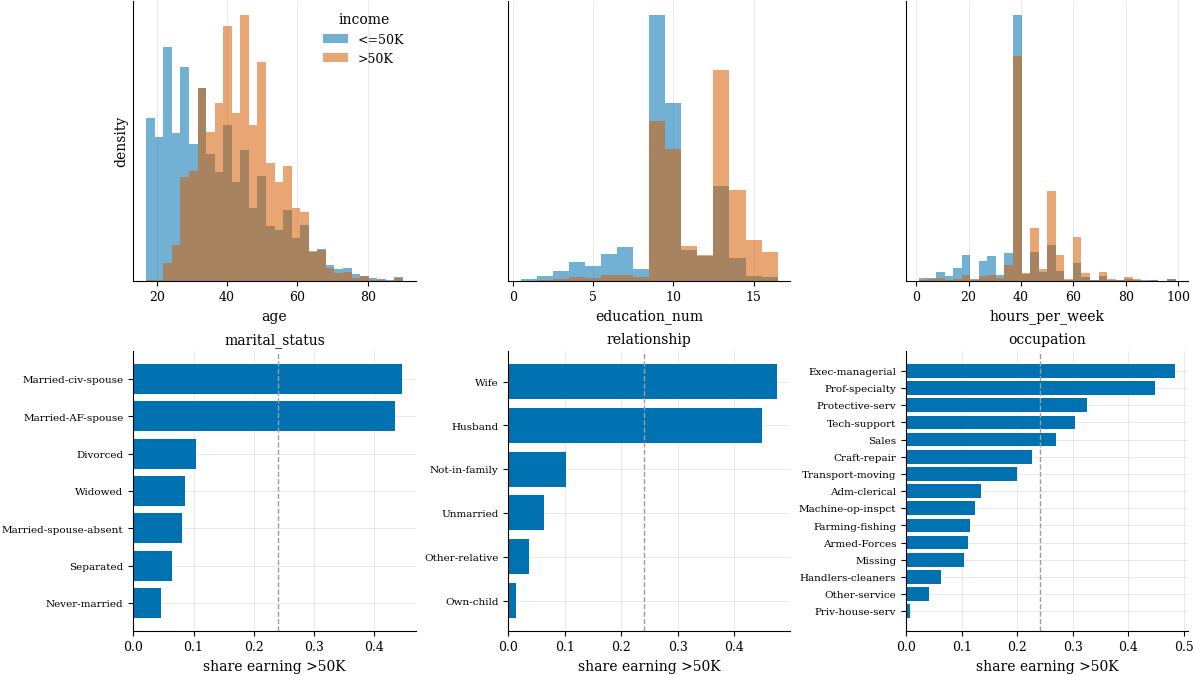

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(12.0, 6.8))
for ax, col in zip(axes[0], ["age", "education_num", "hours_per_week"]):
    edges = np.arange(0.5, 17.0) if col == "education_num" else np.histogram_bin_edges(train_raw[col], 30)
    for k, (color, label) in enumerate([(C0, "<=50K"), (C1, ">50K")]):
        ax.hist(train_raw.loc[y_full == k, col], bins=edges, density=True, alpha=0.55, color=color, label=label)
    ax.set_xlabel(col)
    ax.set_yticks([])
axes[0, 0].set_ylabel("density")
axes[0, 0].legend(title="income")
for ax, col in zip(axes[1], ["marital_status", "relationship", "occupation"]):
    share = y_full.groupby(train_raw[col].fillna("Missing")).mean().sort_values()
    ax.barh(share.index, share.values, color=C0)
    ax.axvline(y_full.mean(), color=CX, ls="--", lw=1)
    ax.set_xlabel("share earning >50K")
    ax.set_title(col, fontsize=10)
    ax.tick_params(axis="y", labelsize=7.5)
plt.show()

Marriage, education and age separate the groups strongly; hours per week less so. Notice also that
the bottom-left and bottom-middle panels tell a similar story: `relationship` and `marital_status`
overlap. How much?

In [8]:
print(pd.crosstab(train_raw["relationship"], train_raw["sex"]), "\n")
spouses = train_raw["relationship"].isin(["Husband", "Wife"])
print(pd.crosstab(train_raw.loc[spouses, "relationship"], train_raw.loc[spouses, "marital_status"]))

sex             Female   Male
relationship                 
Husband              1  13192
Not-in-family     3875   4430
Other-relative     430    551
Own-child         2245   2823
Unmarried         2654    792
Wife              1566      2 

marital_status  Married-AF-spouse  Married-civ-spouse
relationship                                         
Husband                         9               13184
Wife                           12                1556


Every "Husband" is married, and all but one are recorded as male; every "Wife" is married. So the
single answer "Husband" already says *male* and *married*. A model that adds up evidence column by
column counts that one fact up to three times. Remember this in &sect;4 and &sect;8.

> &#9888;&#65039; **Watch out.** The table contains `sex`, `race` and `native_country`, and it records
> the pay gaps of 1994. We use them as ordinary inputs because this is a benchmark. A real decision
> about people would need a much closer look at what these inputs do (exercise 7).

## 2. Split first, then preprocess by hand

From here on the test file is locked away. We keep the columns we need and give missing categories
their own value:

In [9]:
NUMERIC = ["age", "education_num", "capital_gain", "capital_loss", "hours_per_week"]
CATEGORICAL = ["workclass", "marital_status", "occupation", "relationship", "race", "sex",
               "native_country"]


def clean(raw):
    "the modeling table: no fnlwgt or education, '?' becomes a category, labels become 0/1"
    X = raw[NUMERIC + CATEGORICAL].copy()
    X[CATEGORICAL] = X[CATEGORICAL].fillna("Missing")
    y = raw["income"].str.rstrip(".").eq(">50K").astype(int).to_numpy()
    return X, y


X_pool, y_pool = clean(train_raw)            # all labeled training rows
X_test, y_test = clean(test_raw)             # locked until section 7
X_dev, _, y_dev, _ = train_test_split(X_pool, y_pool, train_size=N_TRAIN, stratify=y_pool,
                                      random_state=SEED)
folds = list(StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED).split(X_dev, y_dev))
print(f"development sample: {len(X_dev):,} of {len(X_pool):,} training rows, {y_dev.mean():.1%} earn >50K")
print(f"5 folds of {len(folds[0][1]):,} validation rows each;  test file (locked): {len(X_test):,} rows")

development sample: 5,000 of 32,561 training rows, 24.1% earn >50K
5 folds of 1,000 validation rows each;  test file (locked): 16,281 rows


> &#9888;&#65039; **Why only 5,000 of the 32,561 training rows?** A kernel SVM's training time grows
> faster than the number of rows, and its prediction time with the number of support vectors it
> keeps (&sect;5 measures the training time and the support vectors, &sect;7 the prediction time).
> With 5,000 rows every model trains in seconds, and the comparison is fair: **all four get exactly
> the same 5,000 people.** That is a choice, not a law of nature, and &sect;8 checks whether the
> order of the models survives when we use all 32,561 rows.

### The trap: encoding the two files separately

The natural first try is `pd.get_dummies`, once on the training rows and once on the test rows:

In [10]:
dummies_dev = pd.get_dummies(X_dev[CATEGORICAL])
dummies_test = pd.get_dummies(X_test[CATEGORICAL])
print(f"columns: {dummies_dev.shape[1]} (development rows) vs {dummies_test.shape[1]} (test rows)")
print("present in one but not the other:", sorted(set(dummies_dev.columns) ^ set(dummies_test.columns)))

columns: 84 (development rows) vs 85 (test rows)
present in one but not the other: ['native_country_Hungary']


A model trained on one set of columns cannot score rows that have another. Worse, if the counts
happened to match, the columns could still differ or come in a different order, and nothing would
complain. The cure is to **learn the encoding from the training rows and apply that same encoding to
everything else**, which is what `fit` and `transform` mean in scikit-learn. Here is the whole
preprocessing in one small class:

In [11]:
class TablePrep:
    """Table -> numeric matrix. Everything is LEARNED in fit(), from training rows only."""

    def __init__(self, scale=True):
        self.scale = scale

    def fit(self, X):
        # one 0/1 column per category; categories seen fewer than 20 times share one "=other"
        # column, which also receives categories the training rows never showed
        self.encoder = OneHotEncoder(min_frequency=20, handle_unknown="infrequent_if_exist",
                                     sparse_output=False).fit(X[CATEGORICAL])
        self.scaler = StandardScaler().fit(self._encode(X)) if self.scale else None
        return self

    def _encode(self, X):
        return np.hstack([X[NUMERIC].to_numpy(float), self.encoder.transform(X[CATEGORICAL])])

    def transform(self, X):
        M = self._encode(X)
        return self.scaler.transform(M) if self.scale else M

    def names(self):
        return NUMERIC + [n.replace("_infrequent_sklearn", "=other")
                          for n in self.encoder.get_feature_names_out()]


prep = TablePrep().fit(X_dev)
print(f"{len(prep.names())} columns: {len(NUMERIC)} numbers + {len(prep.names()) - len(NUMERIC)} indicators")
print("pooled columns:", [n for n in prep.names() if n.endswith("=other")])
print("development matrix", prep.transform(X_dev).shape, "  test matrix", prep.transform(X_test).shape)

56 columns: 5 numbers + 51 indicators
pooled columns: ['workclass=other', 'marital_status=other', 'occupation=other', 'native_country=other']


development matrix (5000, 56)   test matrix (16281, 56)


Columns without rare categories (`race`, `sex`, `relationship`) have no `=other` column; a category
they never saw would simply get zeros everywhere.

### One evaluation loop for every model

Cross-validation by hand (`cv_by_hand` below; scikit-learn's ready-made `cross_validate` would hide
exactly the step we want to see): for each of the 5 folds, fit the preprocessing **and** the model on
the other four folds, then score the held-out fold. Refitting `TablePrep` inside the loop is the point:
the held-out fold must not influence the category lists or the scaling, exactly as the test file
must not. The loop also keeps every row's **out-of-fold score** (the score given by the one model
that never saw that row); &sect;7 uses them to choose thresholds.

In [12]:
def score_of(model, X):
    "a number per row that ranks people, and the model's own cut-off on that number"
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1], 0.5         # probability of >50K
    return model.decision_function(X), 0.0                # SVM: signed distance to the boundary


def cv_by_hand(make_model, scale=True, table=False, train_auc=False, X=None, y=None, splits=None):
    """K-fold CV (default: the development sample and its 5 folds), preprocessing refitted
    inside every fold. Returns validation AUC and accuracy, per-fold AUCs, out-of-fold scores."""
    X, y, splits = (X_dev, y_dev, folds) if X is None else (X, y, splits)
    t0 = time.perf_counter()
    aucs, accs, fit_aucs, oof = [], [], [], np.zeros(len(y))
    for train_idx, val_idx in splits:
        X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
        if not table:                                     # most models want a numeric matrix
            fold_prep = TablePrep(scale=scale).fit(X_tr)  # learned from the training part ONLY
            X_tr, X_va = fold_prep.transform(X_tr), fold_prep.transform(X_va)
        model = make_model().fit(X_tr, y[train_idx])
        oof[val_idx], cut = score_of(model, X_va)
        aucs.append(roc_auc_score(y[val_idx], oof[val_idx]))
        accs.append(np.mean((oof[val_idx] > cut) == y[val_idx]))
        if train_auc:
            fit_aucs.append(roc_auc_score(y[train_idx], score_of(model, X_tr)[0]))
    return {"auc": np.mean(aucs), "auc_sd": np.std(aucs), "aucs": np.array(aucs), "acc": np.mean(accs),
            "train_auc": np.mean(fit_aucs) if train_auc else np.nan, "oof": oof, "cut": cut,
            "seconds": time.perf_counter() - t0}

**Why AUC?** The ROC AUC is the probability that a randomly chosen high earner is ranked above a
randomly chosen low earner: 1.0 is a perfect ranking and 0.5 a coin flip. It needs only a ranking,
so it compares a probability (logistic regression, naive Bayes, a tree) with an SVM's decision value
on equal terms, and it does not depend on any threshold. Accuracy is reported alongside, at each
model's own default cut-off (probability 0.5, or decision value 0 for an SVM).

Every section below ends by adding its best setting to a **scoreboard**. The first row is the
baseline:

In [13]:
board = [{"model": "always '<=50K'", "CV AUC": 0.5, "AUC sd": 0.0, "CV accuracy": 1 - y_dev.mean(),
          "setting": "-", "CV seconds": 0.0}]


def add_to_board(name, result, setting):
    board.append({"model": name, "CV AUC": result["auc"], "AUC sd": result["auc_sd"],
                  "CV accuracy": result["acc"], "setting": setting, "CV seconds": result["seconds"]})
    return pd.DataFrame(board).set_index("model").round(3)


pd.DataFrame(board).set_index("model").round(3)

,CV AUC,AUC sd,CV accuracy,setting,CV seconds
model,,,,,
always '<=50K',0.5,0.0,0.759,-,0.0


## 3. Logistic regression (Lecture 04)

A weighted sum of the 56 columns, passed through a sigmoid. Its one knob is `C`, the inverse
strength of the L2 penalty from Session 03: a small `C` pulls the weights hard toward zero.

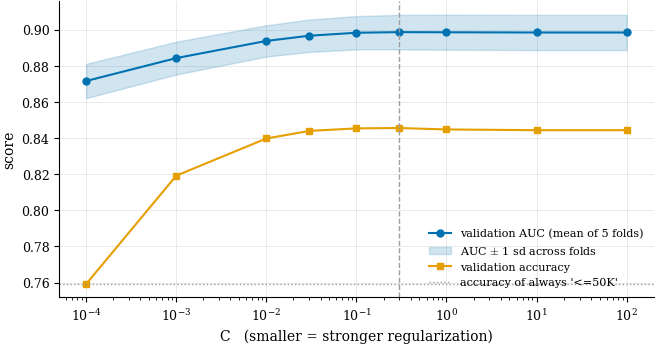

C = 0.0001  AUC 0.872 +- 0.009   accuracy 0.759
C = 0.001   AUC 0.884 +- 0.009   accuracy 0.819
C = 0.01    AUC 0.894 +- 0.009   accuracy 0.840
C = 0.03    AUC 0.897 +- 0.009   accuracy 0.844
C = 0.1     AUC 0.898 +- 0.009   accuracy 0.845
C = 0.3     AUC 0.899 +- 0.010   accuracy 0.846
C = 1       AUC 0.899 +- 0.010   accuracy 0.845
C = 10      AUC 0.899 +- 0.010   accuracy 0.844
C = 100     AUC 0.899 +- 0.010   accuracy 0.844

chosen: C = 0.3
C = 0.0001 predicts >50K for 0.0% of the validation rows
from C = 0.03 on, the mean AUC moves by 0.002; the fold-to-fold sd is about 0.009


In [14]:
C_GRID = [1e-4, 1e-3, 1e-2, 0.03, 0.1, 0.3, 1, 10, 100]
lr_cv = {C: cv_by_hand(lambda C=C: LogisticRegression(C=C, max_iter=1000)) for C in C_GRID}
best_C = max(lr_cv, key=lambda C: lr_cv[C]["auc"])

auc = np.array([lr_cv[C]["auc"] for C in C_GRID])
sd = np.array([lr_cv[C]["auc_sd"] for C in C_GRID])
fig, ax = plt.subplots(figsize=(6.6, 3.5))
ax.semilogx(C_GRID, auc, "-o", color=C0, label="validation AUC (mean of 5 folds)")
ax.fill_between(C_GRID, auc - sd, auc + sd, color=C0, alpha=0.18, label="AUC $\\pm$ 1 sd across folds")
ax.semilogx(C_GRID, [lr_cv[C]["acc"] for C in C_GRID], "-s", color=CN, label="validation accuracy")
ax.axhline(1 - y_dev.mean(), color=CX, ls=":", lw=1, label="accuracy of always '<=50K'")
ax.axvline(best_C, color=CX, ls="--", lw=1)
ax.set_xlabel("C   (smaller = stronger regularization)")
ax.set_ylabel("score")
ax.legend(fontsize=8)
plt.show()
for C in C_GRID:
    print(f"C = {C:<7g} AUC {lr_cv[C]['auc']:.3f} +- {lr_cv[C]['auc_sd']:.3f}   accuracy {lr_cv[C]['acc']:.3f}")
print(f"\nchosen: C = {best_C:g}")
print(f"C = 0.0001 predicts >50K for {np.mean(lr_cv[1e-4]['oof'] > 0.5):.1%} of the validation rows")
flat = [lr_cv[C]["auc"] for C in C_GRID if C >= 0.03]
print(f"from C = 0.03 on, the mean AUC moves by {max(flat) - min(flat):.3f}; "
      f"the fold-to-fold sd is about {np.mean([lr_cv[C]['auc_sd'] for C in C_GRID]):.3f}")

Two things to read off the curve.

* With the strongest penalty, `C` = 0.0001, the model still **ranks** people quite well (AUC
  0.872), but it predicts "&gt;50K" for nobody: shrunk toward zero, every predicted probability
  stays below 0.5, so its accuracy is exactly the baseline. AUC and accuracy measure different
  things.
* From `C` = 0.03 on, the curve is flat: the mean AUC moves by 0.002, a fifth of the fold-to-fold
  spread. With 5,000 rows and 56 columns this knob barely matters, and not every hyperparameter
  deserves a big search.

In [15]:
add_to_board("logistic regression", lr_cv[best_C], f"C={best_C:g}")

,CV AUC,AUC sd,CV accuracy,setting,CV seconds
model,,,,,
always '<=50K',0.500,0.00,0.759,-,0.00
logistic regression,0.899,0.01,0.846,C=0.3,0.38


## 4. Naive Bayes, the generative contender (Lecture 05)

A generative classifier models how each class *produces* its data, $p(\mathbf{x}\mid y)$, and turns
it around with Bayes' rule. Naive Bayes keeps that tractable by assuming the features are
independent **given the class**, so the log-posterior is a sum with one term per feature:

$$\log p(y\mid\mathbf{x}) \;=\; \text{const} \;+\; \log p(y) \;+\; \sum_{j}\log p(x_j\mid y).$$

For every column we must pick a distribution $p(x_j\mid y)$, and that choice *is* the model. We try
three.

### Choice 1: a Gaussian for every column of the matrix

This is what you get by handing the 56-column matrix to `GaussianNB`:

In [16]:
gauss_cv = cv_by_hand(GaussianNB)
print(f"GaussianNB on the 56-column matrix: AUC {gauss_cv['auc']:.3f}, accuracy {gauss_cv['acc']:.3f}"
      f"   (always '<=50K': accuracy {1 - y_dev.mean():.3f})")

g = GaussianNB().fit(prep.transform(X_dev), y_dev)
j = int(np.argmin(g.var_.min(axis=0)))            # the column with the smallest within-class variance
k = int(np.argmin(g.var_[:, j]))                  # ... and the class where it happens
one = prep.transform(X_dev)[:, j].max()           # the scaled value of a '1' in that column
log_density = -0.5 * np.log(2 * np.pi * g.var_[k, j]) - (one - g.theta_[k, j]) ** 2 / (2 * g.var_[k, j])
print(f"\ncolumn '{prep.names()[j]}': variance {g.var_[k, j]:.0e} in class {k} "
      f"(none of its {np.sum(y_dev == k):,} people has a 1 there)")
print(f"a person who does have a 1 gets log p(x_j | y={k}) = {log_density:.2e} from that column alone")

GaussianNB on the 56-column matrix: AUC 0.816, accuracy 0.548   (always '<=50K': accuracy 0.759)

column 'workclass=other': variance 1e-09 in class 1 (none of its 1,204 people has a 1 there)
a person who does have a 1 gets log p(x_j | y=1) = -2.51e+11 from that column alone


> &#9888;&#65039; **Watch out.** A 0/1 column is not a bell curve. In one class nobody has a 1 in a
> rare column, so its fitted variance is essentially zero (`GaussianNB` adds only a tiny safety
> term), and a single person with a 1 there gets a log-likelihood of about &minus;2.5&times;10<sup>11</sup>
> from that column alone: one rare indicator outvotes all the others. The wrong likelihood does not
> fail loudly. It still ranks people somewhat (AUC 0.816), but its yes/no answers are worse than
> always answering "&le;50K" (accuracy 0.548 against 0.759).

### Choice 2: the right distribution for each type of column

Give each number a Gaussian per class, and each category a table of frequencies per class (with
add-one smoothing). `GaussianNB` fits the Gaussians and `CategoricalNB` the frequency tables, but
we **add up the evidence ourselves**, because that sum *is* the naive assumption:

$$\log p(y\mid\mathbf{x}) = \text{const} + \underbrace{\log p(y) + \sum_{\text{numbers}}\log p(x_j\mid y)}_{\texttt{GaussianNB}}
\;+\; \sum_{\text{categories}}\log p(x_j\mid y).$$

The first part is what `GaussianNB.predict_joint_log_proba` returns (before normalizing). For the
categories we look up each person's category in each fitted table (`feature_log_prob_`) and add.
Writing the sum out has a second payoff: a category that the training rows never showed carries no
information about the class, so we simply **leave that column out of the sum**. That is how a
generative model handles a missing value.

In [17]:
class MixedNaiveBayes:
    """Naive Bayes for a mixed table: a Gaussian per class for each number,
    a frequency table per class for each category."""

    def __init__(self, drop=()):
        self.categorical = [c for c in CATEGORICAL if c not in drop]   # used in section 8

    def fit(self, X, y):
        self.codes = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
        self.codes.fit(X[self.categorical])                  # each category -> 0, 1, 2, ...; unseen -> -1
        self.gauss = GaussianNB().fit(X[NUMERIC].to_numpy(float), y)
        self.cat = CategoricalNB(alpha=1.0).fit(self.codes.transform(X[self.categorical]).astype(int), y)
        return self

    def evidence(self, tables, codes):
        "sum over columns of log p(x_j | y); a code of -1 (never seen in training) adds nothing"
        total = np.zeros((len(codes), 2))
        for j, table in enumerate(tables):                   # table[y, k] = log p(x_j = k | y)
            seen = codes[:, j] >= 0
            total[seen] += table[:, codes[seen, j]].T
        return total

    def log_joint(self, X):
        "log p(y) + sum_j log p(x_j | y): one column per class, before normalizing"
        codes = self.codes.transform(X[self.categorical]).astype(int)
        return (self.gauss.predict_joint_log_proba(X[NUMERIC].to_numpy(float))   # log p(y) + the numbers
                + self.evidence(self.cat.feature_log_prob_, codes))             # + the categories

    def predict_proba(self, X):
        joint = self.log_joint(X)
        return np.exp(joint - logsumexp(joint, axis=1, keepdims=True))        # Bayes' rule, normalized


check_nb = MixedNaiveBayes().fit(X_dev, y_dev)
codes = check_nb.codes.transform(X_dev[CATEGORICAL]).astype(int)
ours = check_nb.cat.class_log_prior_ + check_nb.evidence(check_nb.cat.feature_log_prob_, codes)
print("our sum over the category tables equals CategoricalNB's own:",
      np.allclose(ours, check_nb.cat.predict_joint_log_proba(codes)))

mixed_cv = cv_by_hand(MixedNaiveBayes, table=True)
print(f"Gaussian numbers + category tables: AUC {mixed_cv['auc']:.3f}, accuracy {mixed_cv['acc']:.3f}")
unseen = sum(int((~X_dev.iloc[va][c].isin(X_dev.iloc[tr][c])).sum()) for tr, va in folds for c in CATEGORICAL)
print(f"validation values whose category never appeared in their fold's training part: {unseen}")

our sum over the category tables equals CategoricalNB's own: True
Gaussian numbers + category tables: AUC 0.882, accuracy 0.814


validation values whose category never appeared in their fold's training part: 4


The check confirms that our hand-written sum is exactly what `CategoricalNB` computes. And the
unseen categories are not a theoretical nicety: even inside our own folds, a few validation values
carry a category that the fold's training part never showed. With the sum written out, such a value
simply contributes nothing.

### Choice 3: bins instead of bell curves

`capital_gain` is zero for most people and huge for a few, and `age` is skewed: neither looks like a
Gaussian. Cutting each number into quantile bins and counting the bins like categories lets the data
choose the shape. The whole model then becomes one `CategoricalNB`:

In [18]:
class BinnedNaiveBayes(MixedNaiveBayes):
    """All-categorical naive Bayes: each number is cut into quantile bins first."""

    def __init__(self, n_bins=20, drop=()):
        super().__init__(drop)
        self.n_bins = n_bins

    def fit(self, X, y):
        self.codes = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
        self.codes.fit(X[self.categorical])
        with warnings.catch_warnings():      # columns full of zeros give equal quantiles: those bins merge
            warnings.filterwarnings("ignore", message="(Bins whose width|Feature .* is constant)",
                                    category=UserWarning)
            self.binner = KBinsDiscretizer(n_bins=self.n_bins, encode="ordinal", strategy="quantile",
                                           quantile_method="averaged_inverted_cdf")
            self.binner.fit(X[NUMERIC].to_numpy(float))
        sizes = [len(edges) - 1 for edges in self.binner.bin_edges_] + [len(c) for c in self.codes.categories_]
        self.cat = CategoricalNB(alpha=1.0, min_categories=sizes).fit(self._table(X), y)
        return self

    def _table(self, X):
        bins = self.binner.transform(X[NUMERIC].to_numpy(float)).astype(int)
        return np.hstack([bins, self.codes.transform(X[self.categorical]).astype(int)])

    def log_joint(self, X):
        return self.cat.class_log_prior_ + self.evidence(self.cat.feature_log_prob_, self._table(X))


BIN_GRID = [5, 10, 20, 40, 80]
nb_cv = {b: cv_by_hand(lambda b=b: BinnedNaiveBayes(n_bins=b), table=True) for b in BIN_GRID}
best_bins = max(nb_cv, key=lambda b: nb_cv[b]["auc"])
for b, r in nb_cv.items():
    print(f"{b:>2} bins asked for: AUC {r['auc']:.3f} +- {r['auc_sd']:.3f}   accuracy {r['acc']:.3f}")
fitted = BinnedNaiveBayes(n_bins=best_bins).fit(X_dev, y_dev)
print(f"\nchosen: {best_bins} bins; bins actually used per number:",
      dict(zip(NUMERIC, [len(e) - 1 for e in fitted.binner.bin_edges_])))

 5 bins asked for: AUC 0.872 +- 0.007   accuracy 0.791
10 bins asked for: AUC 0.873 +- 0.007   accuracy 0.793
20 bins asked for: AUC 0.890 +- 0.010   accuracy 0.809
40 bins asked for: AUC 0.895 +- 0.012   accuracy 0.811
80 bins asked for: AUC 0.895 +- 0.012   accuracy 0.812

chosen: 80 bins; bins actually used per number: {'age': 49, 'education_num': 14, 'capital_gain': 7, 'capital_loss': 4, 'hours_per_week': 24}


No column gets all the bins it asks for. `age` and `hours_per_week` have many repeated values (a
large share of people work exactly 40 hours), `education_num` has only 16 distinct values, and
`capital_gain` and `capital_loss` are zero so often that most of their quantiles coincide. Equal bin
edges are merged; that is the warning we silenced on purpose. Notice also that 40 and 80 bins score
the same AUC: the largest value in the grid won, but by less than the last digit, so the search has
gone far enough.

The three choices side by side:

In [19]:
choices = {"Gaussian for every matrix column": gauss_cv, "Gaussian numbers + category tables": mixed_cv,
           f"bins ({best_bins}) + category tables": nb_cv[best_bins]}
for name, r in choices.items():
    print(f"{name:36s} AUC {r['auc']:.3f} +- {r['auc_sd']:.3f}   accuracy {r['acc']:.3f}")
add_to_board("naive Bayes", nb_cv[best_bins], f"{best_bins} bins")

Gaussian for every matrix column     AUC 0.816 +- 0.023   accuracy 0.548
Gaussian numbers + category tables   AUC 0.882 +- 0.012   accuracy 0.814
bins (80) + category tables          AUC 0.895 +- 0.012   accuracy 0.812


,CV AUC,AUC sd,CV accuracy,setting,CV seconds
model,,,,,
always '<=50K',0.500,0.000,0.759,-,0.000
logistic regression,0.899,0.010,0.846,C=0.3,0.380
naive Bayes,0.895,0.012,0.812,80 bins,0.112


> &#11088; **Key idea.** A generative model is only as good as the distributions you give it. Same
> algorithm, same rows: by changing only the likelihood, the AUC goes from 0.816 to 0.895 and the
> accuracy from 0.548 to 0.812.

Compare the scoreboard rows: naive Bayes now **ranks** almost as well as logistic regression (AUC
0.895 against 0.899), yet its **accuracy** is about three and a half points lower (0.812 against
0.846). Same ranking, worse yes/no answers: &sect;7 and &sect;8 explain why.

## 5. Support vector machines (Lectures 06&ndash;07)

First the **linear** SVM. With 5,000 rows and 56 columns we solve the primal problem (`dual=False`),
which is the fast and deterministic choice when there are many more rows than columns.

In [20]:
SVM_C_GRID = [1e-3, 1e-2, 0.1, 1]
svm_cv = {C: cv_by_hand(lambda C=C: LinearSVC(C=C, dual=False)) for C in SVM_C_GRID}
best_C_svm = max(svm_cv, key=lambda C: svm_cv[C]["auc"])
for C, r in svm_cv.items():
    print(f"linear SVM, C = {C:<6g} AUC {r['auc']:.3f} +- {r['auc_sd']:.3f}   accuracy {r['acc']:.3f}"
          f"   ({r['seconds']:.1f} s for 5 folds)")
print(f"\nchosen: C = {best_C_svm:g}")

linear SVM, C = 0.001  AUC 0.894 +- 0.010   accuracy 0.841   (0.3 s for 5 folds)
linear SVM, C = 0.01   AUC 0.898 +- 0.009   accuracy 0.847   (0.4 s for 5 folds)
linear SVM, C = 0.1    AUC 0.899 +- 0.009   accuracy 0.847   (0.5 s for 5 folds)
linear SVM, C = 1      AUC 0.899 +- 0.009   accuracy 0.847   (0.6 s for 5 folds)

chosen: C = 0.1


Now the **RBF kernel**, which can bend the boundary. It has two knobs: `C` (how much a margin
violation costs) and $\gamma$ (how far one training point's influence reaches: a large $\gamma$
means a short reach and a wiggly boundary). Each cell of the grid below is a full 5-fold
cross-validation. **This cell takes one to two minutes**, which is itself part of the comparison.

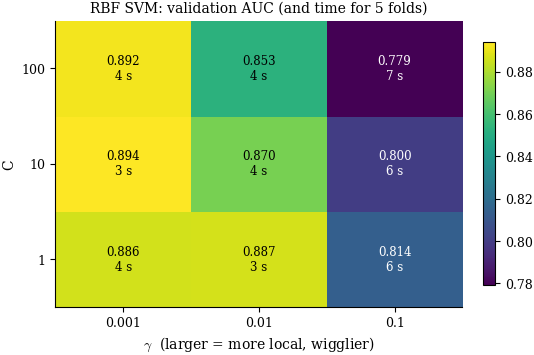

grid computed in 40 s
best RBF: C = 10, gamma = 0.001: AUC 0.894
RBF minus linear SVM, fold by fold: -0.0066, -0.0080, -0.0031, -0.0050, -0.0004   (mean -0.0046)
time for 5 folds: RBF 3.2 s vs linear 0.5 s


In [21]:
C_RBF, GAMMAS = [1, 10, 100], [1e-3, 1e-2, 1e-1]
rbf_cv = {(C, g): cv_by_hand(lambda C=C, g=g: SVC(C=C, gamma=g, cache_size=1000))
          for C in C_RBF for g in GAMMAS}
best_rbf = max(rbf_cv, key=lambda k: rbf_cv[k]["auc"])

grid = np.array([[rbf_cv[C, g]["auc"] for g in GAMMAS] for C in C_RBF])
fig, ax = plt.subplots(figsize=(5.4, 3.6))
im = ax.imshow(grid, cmap="viridis", origin="lower", aspect="auto")
for a, C in enumerate(C_RBF):
    for b, g in enumerate(GAMMAS):
        ax.text(b, a, f"{grid[a, b]:.3f}\n{rbf_cv[C, g]['seconds']:.0f} s", ha="center", va="center",
                fontsize=8.5, color="white" if grid[a, b] < grid.mean() else "black")
ax.set_xticks(range(len(GAMMAS)), [f"{g:g}" for g in GAMMAS])
ax.set_yticks(range(len(C_RBF)), [f"{C:g}" for C in C_RBF])
ax.set_xlabel(r"$\gamma$  (larger = more local, wigglier)")
ax.set_ylabel("C")
ax.set_title("RBF SVM: validation AUC (and time for 5 folds)", fontsize=10)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.85)
plt.show()

gap = rbf_cv[best_rbf]["aucs"] - svm_cv[best_C_svm]["aucs"]          # same folds: a paired comparison
print(f"grid computed in {sum(r['seconds'] for r in rbf_cv.values()):.0f} s")
print(f"best RBF: C = {best_rbf[0]:g}, gamma = {best_rbf[1]:g}: AUC {rbf_cv[best_rbf]['auc']:.3f}")
print("RBF minus linear SVM, fold by fold:", ", ".join(f"{d:+.4f}" for d in gap), f"  (mean {gap.mean():+.4f})")
print(f"time for 5 folds: RBF {rbf_cv[best_rbf]['seconds']:.1f} s vs linear {svm_cv[best_C_svm]['seconds']:.1f} s")

Read the grid from left to right. As $\gamma$ grows, each training point's influence shrinks and the
boundary starts to follow individual people; at the largest $\gamma$ the validation AUC drops in
every row: that is overfitting. The best RBF setting sits in the **small-$\gamma$** column, at the
edge of the grid, where the kernel is so wide that the boundary is almost flat. That is no accident:
as $\gamma\to0$, with `C` growing to match, an RBF SVM turns into a linear SVM (Keerthi &amp; Lin,
2003). Even so, the best RBF setting is **behind the linear SVM in all five folds** (in one of them
only by 0.0004), by 0.0046 on average: a small gap, but a consistent one. On this table the kernel's
extra flexibility buys nothing. We take the linear SVM forward; the RBF SVM stays in the final table
for the record.

What does the kernel cost? Fit the chosen RBF SVM on growing slices of the development sample:

In [22]:
slices, fit_seconds, n_support = [1_000, 2_000, 4_000], [], []
for n in slices:
    M = prep.transform(X_dev.iloc[:n])
    t0 = time.perf_counter()
    model = SVC(C=best_rbf[0], gamma=best_rbf[1], cache_size=1000).fit(M, y_dev[:n])
    fit_seconds.append(time.perf_counter() - t0)
    n_support.append(model.n_support_.sum())
for n, t, k in zip(slices, fit_seconds, n_support):
    print(f"{n:5,} rows: fit {t:.2f} s, {k:,} support vectors kept ({k / n:.0%} of the rows)")
print(f"each doubling of the rows multiplied the fit time by "
      f"{fit_seconds[1] / fit_seconds[0]:.1f} and {fit_seconds[2] / fit_seconds[1]:.1f}")

1,000 rows: fit 0.03 s, 407 support vectors kept (41% of the rows)
2,000 rows: fit 0.09 s, 806 support vectors kept (40% of the rows)
4,000 rows: fit 0.42 s, 1,534 support vectors kept (38% of the rows)
each doubling of the rows multiplied the fit time by 3.6 and 4.5


The fit time grows much faster than the data (in this run, about fourfold per doubling), and the
model keeps a large, roughly steady share of its training rows as support vectors, all of which are
needed again for **every** prediction. A linear model stores one weight per column, whatever the
number of rows.

In [23]:
add_to_board("linear SVM", svm_cv[best_C_svm], f"C={best_C_svm:g}")
add_to_board("RBF SVM", rbf_cv[best_rbf], f"C={best_rbf[0]:g}, gamma={best_rbf[1]:g}")

,CV AUC,AUC sd,CV accuracy,setting,CV seconds
model,,,,,
always '<=50K',0.500,0.000,0.759,-,0.000
logistic regression,0.899,0.010,0.846,C=0.3,0.380
naive Bayes,0.895,0.012,0.812,80 bins,0.112
linear SVM,0.899,0.009,0.847,C=0.1,0.490
RBF SVM,0.894,0.008,0.842,"C=10, gamma=0.001",3.223


## 6. Decision tree (Lecture 08)

A tree needs no scaling, so it gets the unscaled matrix (`scale=False`); the thresholds then stay in
dollars, years and hours. Its complexity knob here is `min_samples_leaf`: a leaf must hold at least
that many training people. Small leaves memorize, large leaves generalize. The plot adds the
**training** AUC, to make the gap visible.

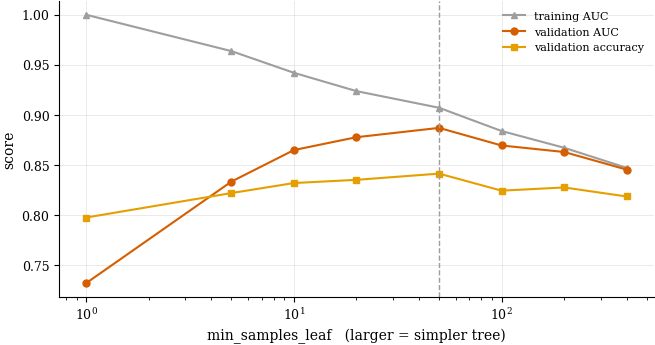

min_samples_leaf = 1    training AUC 1.000   validation AUC 0.732 +- 0.014   accuracy 0.798
min_samples_leaf = 5    training AUC 0.964   validation AUC 0.833 +- 0.016   accuracy 0.822
min_samples_leaf = 10   training AUC 0.942   validation AUC 0.865 +- 0.018   accuracy 0.832
min_samples_leaf = 20   training AUC 0.924   validation AUC 0.878 +- 0.009   accuracy 0.835
min_samples_leaf = 50   training AUC 0.907   validation AUC 0.887 +- 0.011   accuracy 0.841
min_samples_leaf = 100  training AUC 0.884   validation AUC 0.869 +- 0.009   accuracy 0.824
min_samples_leaf = 200  training AUC 0.867   validation AUC 0.863 +- 0.006   accuracy 0.828
min_samples_leaf = 400  training AUC 0.847   validation AUC 0.845 +- 0.004   accuracy 0.819

chosen: min_samples_leaf = 50


In [24]:
LEAF_GRID = [1, 5, 10, 20, 50, 100, 200, 400]
tree_cv = {m: cv_by_hand(lambda m=m: DecisionTreeClassifier(min_samples_leaf=m, random_state=SEED),
                             scale=False, train_auc=True) for m in LEAF_GRID}
best_leaf = max(tree_cv, key=lambda m: tree_cv[m]["auc"])

fig, ax = plt.subplots(figsize=(6.6, 3.5))
ax.semilogx(LEAF_GRID, [tree_cv[m]["train_auc"] for m in LEAF_GRID], "-^", color=CX, label="training AUC")
ax.semilogx(LEAF_GRID, [tree_cv[m]["auc"] for m in LEAF_GRID], "-o", color=C1, label="validation AUC")
ax.semilogx(LEAF_GRID, [tree_cv[m]["acc"] for m in LEAF_GRID], "-s", color=CN, label="validation accuracy")
ax.axvline(best_leaf, color=CX, ls="--", lw=1)
ax.set_xlabel("min_samples_leaf   (larger = simpler tree)")
ax.set_ylabel("score")
ax.legend(fontsize=8)
plt.show()
for m in LEAF_GRID:
    r = tree_cv[m]
    print(f"min_samples_leaf = {m:<4d} training AUC {r['train_auc']:.3f}   validation AUC {r['auc']:.3f}"
          f" +- {r['auc_sd']:.3f}   accuracy {r['acc']:.3f}")
print(f"\nchosen: min_samples_leaf = {best_leaf}")

A fully grown tree (`min_samples_leaf` = 1) fits its training rows perfectly (training AUC 1.000)
and validates poorly (AUC 0.732): the textbook overfitting gap. Larger leaves trade a little
training fit for a lot of validation AUC, up to a point; past it the tree is too coarse.

What did the chosen tree learn? Its first two levels:

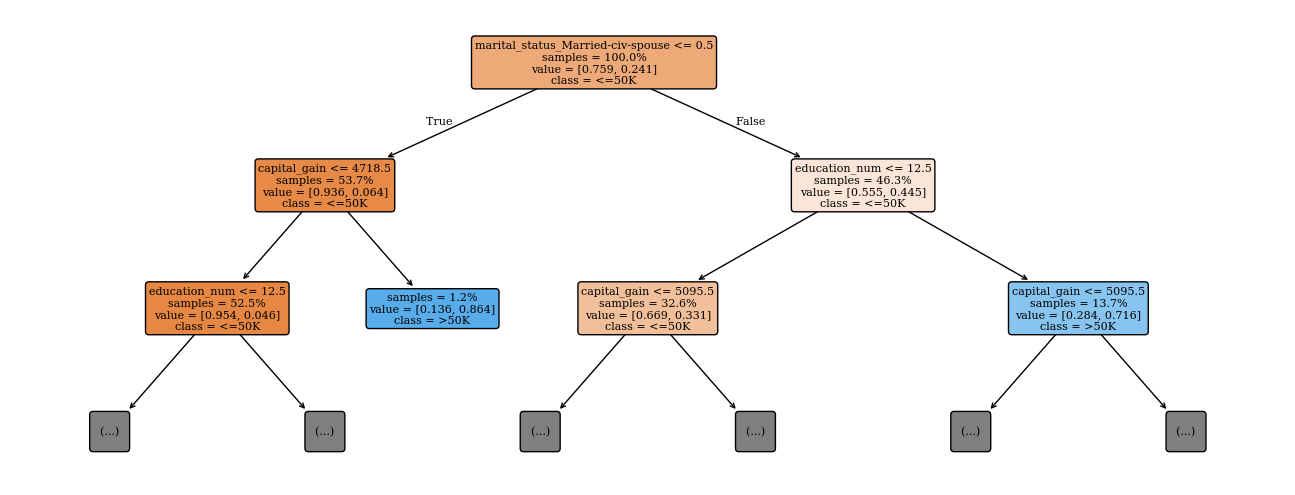

58 leaves, depth 11, splits on 15 of 56 columns


for comparison, a tree of depth 3 (8 rules): validation AUC 0.851 +- 0.015, accuracy 0.842


In [25]:
prep_raw = TablePrep(scale=False).fit(X_dev)
tree = DecisionTreeClassifier(min_samples_leaf=best_leaf, random_state=SEED)
tree.fit(prep_raw.transform(X_dev), y_dev)

fig, ax = plt.subplots(figsize=(13.0, 5.0))
plot_tree(tree, max_depth=2, feature_names=prep_raw.names(), class_names=["<=50K", ">50K"],
          filled=True, impurity=False, proportion=True, rounded=True, fontsize=8, ax=ax)
plt.show()
used = np.unique(tree.tree_.feature[tree.tree_.feature >= 0])
print(f"{tree.get_n_leaves()} leaves, depth {tree.get_depth()}, "
      f"splits on {len(used)} of {len(prep_raw.names())} columns")

shallow_cv = cv_by_hand(lambda: DecisionTreeClassifier(max_depth=3, random_state=SEED), scale=False)
shallow = DecisionTreeClassifier(max_depth=3, random_state=SEED).fit(prep_raw.transform(X_dev), y_dev)
print(f"for comparison, a tree of depth 3 ({shallow.get_n_leaves()} rules): validation AUC "
      f"{shallow_cv['auc']:.3f} +- {shallow_cv['auc_sd']:.3f}, accuracy {shallow_cv['acc']:.3f}")

The rules read like common sense: *Married? Capital gain above about \$5,000? At least a bachelor's
degree* (`education_num` &gt; 12.5)? That readability is the tree's main selling point, but only the
top levels are this readable: the full tree is much bigger. A tree small enough to print on one
page, of depth 3, is a telling comparison (last line): its yes/no answers are as accurate (0.842),
but with only 8 possible scores it ranks people in coarse blocks, and its AUC drops to 0.851.

### Does scaling matter? One question, four answers

Logistic regression and the linear SVM were given scaled columns, the tree unscaled ones, and naive
Bayes never sees a matrix at all. Is that a real difference?

In [26]:
X_scaled, X_unscaled = prep.transform(X_dev), prep_raw.transform(X_dev)

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    lr_scaled = LogisticRegression(C=best_C, max_iter=1000).fit(X_scaled, y_dev)
    lr_unscaled = LogisticRegression(C=best_C, max_iter=1000).fit(X_unscaled, y_dev)
print(f"logistic regression: {lr_scaled.n_iter_[0]} iterations scaled, {lr_unscaled.n_iter_[0]} unscaled"
      f" ({len(caught)} convergence warning(s)); same yes/no answer for "
      f"{np.mean(lr_scaled.predict(X_scaled) == lr_unscaled.predict(X_unscaled)):.1%} of the rows")

svm_unscaled = cv_by_hand(lambda: LinearSVC(C=best_C_svm, dual=False), scale=False)
print(f"linear SVM: validation AUC {svm_cv[best_C_svm]['auc']:.3f} scaled, {svm_unscaled['auc']:.3f} unscaled")

tree_scaled = DecisionTreeClassifier(min_samples_leaf=best_leaf, random_state=SEED).fit(X_scaled, y_dev)
same = np.array_equal(tree_scaled.predict_proba(X_scaled), tree.predict_proba(X_unscaled))
print(f"decision tree: scaled and unscaled trees give identical probabilities: {same}")

logistic regression: 24 iterations scaled, 1000 unscaled (1 convergence warning(s)); same yes/no answer for 98.3% of the rows


linear SVM: validation AUC 0.899 scaled, 0.898 unscaled
decision tree: scaled and unscaled trees give identical probabilities: True


* **Logistic regression** reaches nearly the same answers either way, but on unscaled columns the
  optimizer struggles and stops at its iteration limit: dollars next to 0/1 indicators make a long,
  narrow valley (the "ravine" of notebook 02c).
* **The linear SVM** changes a little: the penalty treats a weight on dollars and a weight on a 0/1
  column alike, so the units decide which weights are cheap.
* **The tree** is exactly invariant: a split asks "above or below?", and scaling preserves order.
* **The RBF SVM** measures *distances*, so the units decide which columns matter at all. Its tuned
  `C` and $\gamma$ are only valid for the scaling they were tuned with.

The scoreboard after cross-validation, before anybody has seen the test labels:

In [27]:
scoreboard = add_to_board("decision tree", tree_cv[best_leaf], f"min_samples_leaf={best_leaf}")
spread = scoreboard["CV AUC"].iloc[1:]
print(f"the five contenders' CV AUCs span {spread.max() - spread.min():.3f}; "
      f"a typical fold-to-fold sd is {scoreboard['AUC sd'].iloc[1:].mean():.3f}")
scoreboard

the five contenders' CV AUCs span 0.012; a typical fold-to-fold sd is 0.010


,CV AUC,AUC sd,CV accuracy,setting,CV seconds
model,,,,,
always '<=50K',0.500,0.000,0.759,-,0.000
logistic regression,0.899,0.010,0.846,C=0.3,0.380
naive Bayes,0.895,0.012,0.812,80 bins,0.112
linear SVM,0.899,0.009,0.847,C=0.1,0.490
RBF SVM,0.894,0.008,0.842,"C=10, gamma=0.001",3.223
decision tree,0.887,0.011,0.841,min_samples_leaf=50,0.288


> &#128161; **Your bet.** On the cross-validated AUC the five contenders sit within 0.012 of each
> other, about one fold-to-fold standard deviation. Before running the next section, decide which of
> those gaps you believe.

## 7. The final exam: one look at the test file

Each contender is refitted, with its chosen setting, on all 5,000 development rows and scored on
the 16,281 test rows: **once**. For the yes/no flag we also choose a **threshold** for every model,
the cut-off that maximizes accuracy on the out-of-fold scores from its cross-validation, i.e. on
training data only. The test file then just reports what happens.

In [28]:
def best_threshold(scores, y):
    "the cut-off with the highest accuracy on out-of-fold training scores"
    candidates = np.quantile(scores, np.linspace(0.30, 0.99, 139))
    accuracy = [np.mean((scores > c) == y) for c in candidates]
    return candidates[int(np.argmax(accuracy))]


matrices = {"scaled": (X_scaled, prep.transform(X_test)), "unscaled": (X_unscaled, prep_raw.transform(X_test)),
            "table": (X_dev, X_test)}
contenders = {   # name: (model with its chosen setting, input, cross-validation result of that setting)
    "logistic regression": (LogisticRegression(C=best_C, max_iter=1000), "scaled", lr_cv[best_C]),
    "naive Bayes": (BinnedNaiveBayes(n_bins=best_bins), "table", nb_cv[best_bins]),
    "linear SVM": (LinearSVC(C=best_C_svm, dual=False), "scaled", svm_cv[best_C_svm]),
    "RBF SVM": (SVC(C=best_rbf[0], gamma=best_rbf[1], cache_size=1000), "scaled", rbf_cv[best_rbf]),
    "decision tree": (DecisionTreeClassifier(min_samples_leaf=best_leaf, random_state=SEED), "unscaled",
                      tree_cv[best_leaf]),
}

test_scores, cuts, rows = {}, {}, []
for name, (model, kind, cv) in contenders.items():
    X_fit, X_score = matrices[kind]
    t0 = time.perf_counter(); model.fit(X_fit, y_dev); fit_s = time.perf_counter() - t0
    t0 = time.perf_counter(); s, default_cut = score_of(model, X_score); predict_s = time.perf_counter() - t0
    test_scores[name], cuts[name] = s, best_threshold(cv["oof"], y_dev)
    rows.append({"model": name, "test AUC": roc_auc_score(y_test, s),
                 "accuracy, default cut": np.mean((s > default_cut) == y_test),
                 "chosen cut": cuts[name],
                 "accuracy, chosen cut": np.mean((s > cuts[name]) == y_test),
                 "log loss": log_loss(y_test, s) if default_cut == 0.5 else np.nan,
                 "fit s": fit_s, "predict s": predict_s})
rows.insert(0, {"model": "always '<=50K'", "test AUC": 0.5, "accuracy, default cut": 1 - y_test.mean(),
                "accuracy, chosen cut": 1 - y_test.mean()})
final = pd.DataFrame(rows).set_index("model")
final.round(3)

,test AUC,"accuracy, default cut","accuracy, chosen cut",chosen cut,log loss,fit s,predict s
model,,,,,,,
always '<=50K',0.500,0.764,0.764,NaN,NaN,NaN,NaN
logistic regression,0.901,0.850,0.850,0.539,0.324,0.022,0.004
naive Bayes,0.902,0.821,0.849,0.822,0.416,0.025,0.050
linear SVM,0.901,0.851,0.852,-0.006,NaN,0.053,0.002
RBF SVM,0.898,0.847,0.847,0.000,NaN,0.664,5.011
decision tree,0.894,0.848,0.843,0.463,0.435,0.015,0.004


What the table says, column by column:

* **AUC.** Logistic regression, naive Bayes and the linear SVM rank people equally well (0.901 to
  0.902); the RBF SVM (0.898) and the tree (0.894) are a little behind.
* **Accuracy at the default cut.** Naive Bayes trails by about three points (0.821 against 0.850
  for logistic regression), despite its AUC.
* **Chosen cut.** For the probabilistic models it is a probability, for the SVMs a decision value.
  Logistic regression's lands near its default of 0.5; naive Bayes's lands far above it.
* **Accuracy at the chosen cut.** Choosing the cut on training data lifts naive Bayes to 0.849 and
  leaves logistic regression where it was (0.850 either way):
  logistic regression's probabilities are already honest, naive Bayes's are not (&sect;8a). For the
  tree the chosen cut does slightly *worse* than
  the default (0.843 against 0.848): a cut-off estimated from 5,000 rows is itself an estimate, and
  a rough one for a model that outputs only a few dozen different probabilities.
* **Log loss** (lower is better) scores the probabilities themselves; &sect;8a looks at them.
* **Time.** The RBF SVM is the only model whose prediction time you notice, seconds instead of
  milliseconds: it compares every test person with each of its support vectors.

Is any of these gaps real? Two different things could move them: **which 5,000 people we trained
on**, and **which 16,281 people happened to be in the test file**. We check both.

### Would another 5,000 people change the order of the models?

Draw five more development samples, refit every model with the same settings, and score the test
file again. (The RBF SVM is left out to keep the cell quick: scoring the test file alone takes it
several seconds, as the table shows.)

In [29]:
draws = []
for r in range(1, 6):
    X_s, _, y_s, _ = train_test_split(X_pool, y_pool, train_size=N_TRAIN, stratify=y_pool,
                                      random_state=SEED + r)
    p_s, p_raw = TablePrep().fit(X_s), TablePrep(scale=False).fit(X_s)
    scores = {
        "logistic regression": LogisticRegression(C=best_C, max_iter=1000).fit(p_s.transform(X_s), y_s)
                               .predict_proba(p_s.transform(X_test))[:, 1],
        "naive Bayes": BinnedNaiveBayes(n_bins=best_bins).fit(X_s, y_s).predict_proba(X_test)[:, 1],
        "linear SVM": LinearSVC(C=best_C_svm, dual=False).fit(p_s.transform(X_s), y_s)
                      .decision_function(p_s.transform(X_test)),
        "decision tree": DecisionTreeClassifier(min_samples_leaf=best_leaf, random_state=SEED)
                         .fit(p_raw.transform(X_s), y_s).predict_proba(p_raw.transform(X_test))[:, 1]}
    draws.append({name: roc_auc_score(y_test, s) for name, s in scores.items()})
draws = pd.DataFrame(draws, index=[f"sample {r}" for r in range(1, 6)])
print(draws.round(4).to_string(), "\n")
diff = draws.sub(draws["logistic regression"], axis=0).drop(columns="logistic regression")
print("test AUC minus logistic regression's, over the 5 samples:")
for name in diff:
    print(f"  {name:14s} mean {diff[name].mean():+.4f}   min {diff[name].min():+.4f}   max {diff[name].max():+.4f}")

          logistic regression  naive Bayes  linear SVM  decision tree
sample 1               0.8994       0.9009      0.8998         0.8928
sample 2               0.9008       0.9003      0.9010         0.8865
sample 3               0.9031       0.9036      0.9035         0.8924
sample 4               0.9012       0.9006      0.9017         0.8900
sample 5               0.9013       0.9036      0.9015         0.8916 

test AUC minus logistic regression's, over the 5 samples:
  naive Bayes    mean +0.0007   min -0.0006   max +0.0023
  linear SVM     mean +0.0004   min +0.0002   max +0.0006
  decision tree  mean -0.0105   min -0.0143   max -0.0065


Over five new samples the linear SVM beats logistic regression **every** time, by 0.0002 to 0.0006
AUC: a perfectly consistent difference and a perfectly useless one. Naive Bayes lands on either side
of logistic regression. The tree is behind every time, by 0.0065 to 0.0143.

### Would another test file change it?

The **bootstrap** answers the second question: draw 16,281 test rows *with replacement* from the
test file, recompute every score, and repeat 500 times. The spread of a difference across those
redraws shows how much of it is test-file luck. Each redraw uses the same rows for every model, so
the comparison stays paired. (It does not cover the training-sample luck above, which is why we
measured that separately.)

test AUC              naive Bayes    minus logistic regression: +0.0008   95% interval [-0.0019, +0.0035]
test AUC              linear SVM     minus logistic regression: -0.0000   95% interval [-0.0006, +0.0006]
test AUC              RBF SVM        minus logistic regression: -0.0031   95% interval [-0.0044, -0.0017]
test AUC              decision tree  minus logistic regression: -0.0073   95% interval [-0.0105, -0.0041]
test accuracy, points naive Bayes    minus logistic regression: -0.1333   95% interval [-0.5622, +0.2489]
test accuracy, points linear SVM     minus logistic regression: +0.1537   95% interval [-0.0061, +0.3071]
test accuracy, points RBF SVM        minus logistic regression: -0.2583   95% interval [-0.5314, +0.0494]
test accuracy, points decision tree  minus logistic regression: -0.7290   95% interval [-1.2378, -0.2179]


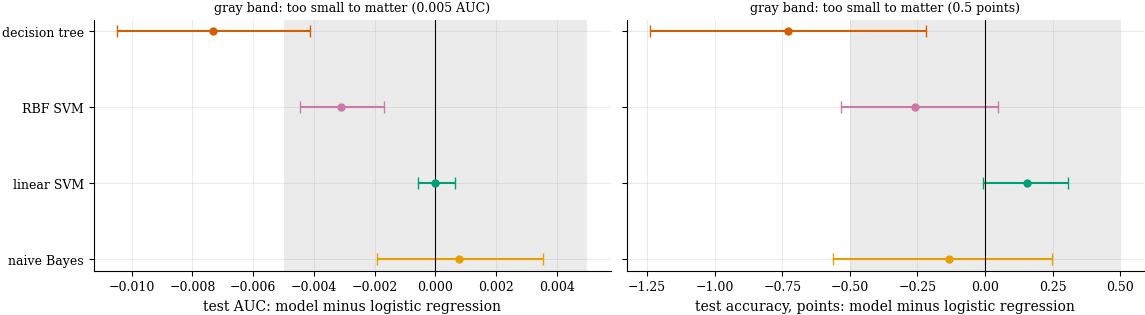

In [30]:
def auc_fast(y, s):
    "ROC AUC through ranks (Mann-Whitney): same value as roc_auc_score, fast enough for 500 redraws"
    ranks = rankdata(s)
    n_pos = y.sum()
    return (ranks[y == 1].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * (len(y) - n_pos))


assert all(np.isclose(auc_fast(y_test, s), roc_auc_score(y_test, s)) for s in test_scores.values())  # ties too
rng = np.random.default_rng(SEED)
redraws = rng.integers(0, len(y_test), size=(500, len(y_test)))      # shared by every model: paired
boot_auc = {n: np.array([auc_fast(y_test[i], s[i]) for i in redraws]) for n, s in test_scores.items()}
correct = {n: (s > cuts[n]) == y_test for n, s in test_scores.items()}
boot_acc = {n: c[redraws].mean(axis=1) for n, c in correct.items()}

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.2), sharey=True)
others = [n for n in test_scores if n != "logistic regression"]
for ax, boot, band, unit, title in [(axes[0], boot_auc, 0.005, 1, "test AUC"),
                                     (axes[1], boot_acc, 0.005, 100, "test accuracy, points")]:
    for i, name in enumerate(others):
        d = (boot[name] - boot["logistic regression"]) * unit
        lo, hi = np.percentile(d, [2.5, 97.5])
        ax.errorbar(d.mean(), i, xerr=[[d.mean() - lo], [hi - d.mean()]], fmt="o", color=COLORS[name],
                    ecolor=COLORS[name], capsize=4)
        print(f"{title:21s} {name:14s} minus logistic regression: {d.mean():+.4f}"
              f"   95% interval [{lo:+.4f}, {hi:+.4f}]")
    ax.axvspan(-band * unit, band * unit, color=CX, alpha=0.2, lw=0)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel(f"{title}: model minus logistic regression")
axes[0].set_yticks(range(len(others)), others)
axes[0].set_title("gray band: too small to matter (0.005 AUC)", fontsize=9)
axes[1].set_title("gray band: too small to matter (0.5 points)", fontsize=9)
plt.show()

The rule for reading this plot: a difference **counts** only if its interval excludes zero (it is
not test-file luck) **and** its estimate lies outside the gray band (it is big enough to matter).
With 16,281 test rows, even tiny gaps become detectable, so the second condition does real work.

* The **tree** is the only model whose deficit counts, and only just: &minus;0.0073 AUC and
  &minus;0.73 accuracy points, both with intervals clear of zero.
* The **RBF SVM**'s AUC deficit (&minus;0.0031) is reproducible but too small to matter.
* **Naive Bayes** and the **linear SVM** cannot be told apart from logistic regression.

> &#128161; **Intuition.** Two sources of luck, two tools. Re-sampling the *training* rows asks "would
> I have built a different model?"; re-sampling the *test* rows asks "would I have measured it
> differently?". A conclusion should survive both. Ours does, for the four models that went through
> both checks: three tied at the top, the tree a little behind. The RBF SVM's small deficit was
> checked only against test-file luck.

Finally, the ROC curves and the yes/no flags themselves, at each model's chosen cut:

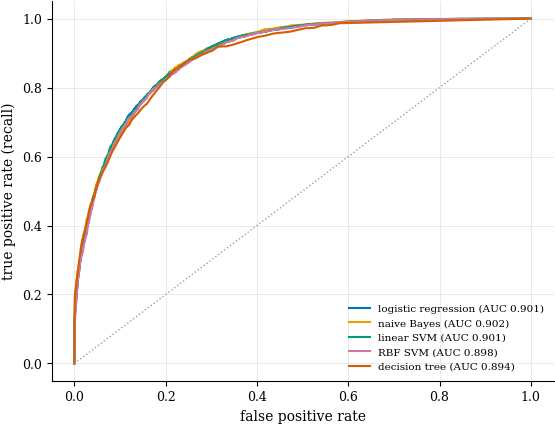

distinct probabilities the tree can output on the test file: 51


,flagged >50K,of them right (TP),wrongly flagged (FP),missed (FN),recall,precision
model,,,,,,
logistic regression,2901,2153,748,1693,0.560,0.742
naive Bayes,3160,2271,889,1575,0.590,0.719
linear SVM,3137,2283,854,1563,0.594,0.728
RBF SVM,3114,2238,876,1608,0.582,0.719
decision tree,3706,2495,1211,1351,0.649,0.673


In [31]:
fig, ax = plt.subplots(figsize=(5.6, 4.3))
for name, s in test_scores.items():
    fpr, tpr, _ = roc_curve(y_test, s)
    ax.plot(fpr, tpr, color=COLORS[name], lw=1.5, label=f"{name} (AUC {final.loc[name, 'test AUC']:.3f})")
ax.plot([0, 1], [0, 1], color=CX, ls=":", lw=1)
ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate (recall)")
ax.legend(fontsize=7.5, loc="lower right")
plt.show()
print(f"distinct probabilities the tree can output on the test file: {len(np.unique(test_scores['decision tree']))}")

flags = []
for name, s in test_scores.items():
    tn, fp, fn, tp = confusion_matrix(y_test, s > cuts[name]).ravel()
    flags.append({"model": name, "flagged >50K": tp + fp, "of them right (TP)": tp, "wrongly flagged (FP)": fp,
                  "missed (FN)": fn, "recall": tp / (tp + fn), "precision": tp / (tp + fp)})
pd.DataFrame(flags).set_index("model").round(3)

The ROC curves lie almost on top of each other. The tree's is the odd one out: it is made of
straight segments because the tree can only output a few dozen different probabilities, so it ranks
people in coarse blocks. The flags show the other side of the same coin: at its chosen cut the tree
flags more people than the others, finding more high earners (higher recall) at the price of more
false alarms (lower precision).

## 8. Beyond the score

Three questions the test AUC does not answer: *can I trust the probabilities?*, *can I read the
model?*, and *what if I had more data?* Everything here uses the test file **after** &sect;7, as an
analysis: nothing is chosen with it any more.

### 8a. Can I trust the probabilities?

When a model says "0.8", do about 80% of those people earn &gt;\$50K? A **reliability diagram** puts
people into 10 bins by predicted probability and plots, for each bin, the observed share of high
earners against the average prediction. A calibrated model sits on the diagonal. The **expected
calibration error** (ECE) is the average vertical gap between the points and the diagonal, weighted
by how many people fall in each bin.

The SVM gives no probabilities, only a decision value. The fix, known as **Platt scaling**, is a
logistic regression (Lecture 04) with a single input &mdash; the SVM's decision value &mdash;
fitted on the out-of-fold values from &sect;5 so that it never sees the rows it calibrates.

logistic regression  ECE 0.005   log loss 0.324
naive Bayes          ECE 0.100   log loss 0.416
linear SVM + Platt   ECE 0.008   log loss 0.324
decision tree        ECE 0.015   log loss 0.435


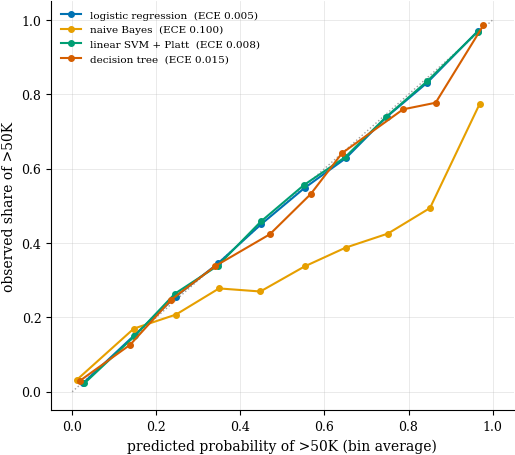


naive Bayes: 45% of its probabilities are below 0.01 or above 0.99; when it says more than 0.9 (average 0.97), 77% of those people earn >50K


In [32]:
platt = LogisticRegression(C=1e6, max_iter=1000).fit(svm_cv[best_C_svm]["oof"].reshape(-1, 1), y_dev)
probabilities = {"logistic regression": test_scores["logistic regression"],
                 "naive Bayes": test_scores["naive Bayes"],
                 "linear SVM + Platt": platt.predict_proba(test_scores["linear SVM"].reshape(-1, 1))[:, 1],
                 "decision tree": test_scores["decision tree"]}


def reliability(p, y, n_bins=10):
    "mean prediction, observed share and count per equal-width bin, and the ECE"
    b = np.minimum((p * n_bins).astype(int), n_bins - 1)
    count = np.bincount(b, minlength=n_bins)
    mean_p = np.bincount(b, weights=p, minlength=n_bins) / np.maximum(count, 1)
    share = np.bincount(b, weights=y, minlength=n_bins) / np.maximum(count, 1)
    return mean_p, share, count, np.sum(count * np.abs(mean_p - share)) / len(y)


fig, ax = plt.subplots(figsize=(5.2, 4.6))
ax.plot([0, 1], [0, 1], color=CX, ls=":", lw=1)
for name, p in probabilities.items():
    mean_p, share, count, ece = reliability(p, y_test)
    keep = count >= 30
    color = COLORS.get(name, CG)
    ax.plot(mean_p[keep], share[keep], "-o", ms=4, color=color, label=f"{name}  (ECE {ece:.3f})")
    print(f"{name:20s} ECE {ece:.3f}   log loss {log_loss(y_test, p):.3f}")
ax.set_xlabel("predicted probability of >50K (bin average)")
ax.set_ylabel("observed share of >50K")
ax.legend(fontsize=7.5, loc="upper left")
plt.show()

p_nb = probabilities["naive Bayes"]
top = p_nb > 0.9
print(f"\nnaive Bayes: {np.mean((p_nb < 0.01) | (p_nb > 0.99)):.0%} of its probabilities are below 0.01 or above 0.99;"
      f" when it says more than 0.9 (average {p_nb[top].mean():.2f}), {y_test[top].mean():.0%} of those people earn >50K")

Logistic regression and the Platt-scaled SVM lie on the diagonal, and the tree is close to it.
**Naive Bayes is overconfident**: its points sag below the diagonal at the top, so its "almost
certainly" means "probably". That is also why its 0.5 cut was in the wrong place in &sect;7.

### 8b. Where the overconfidence comes from: the same fact, counted three times

In &sect;1 we saw that "Husband" already implies *married* and *male*. Logistic regression fits all
weights **together**, so it can split the credit for that one fact among the three columns. Naive
Bayes estimates each column's evidence **separately**, as if the others did not exist, and then adds
everything up. Take one person and change only those three answers:

In [33]:
lr_final = contenders["logistic regression"][0]
nb_final = contenders["naive Bayes"][0]
person = X_test.iloc[[0]].copy()
married = person.assign(relationship="Husband", marital_status="Married-civ-spouse", sex="Male")
single = person.assign(relationship="Not-in-family", marital_status="Never-married", sex="Female")


def log_odds(model, X, matrix):
    p = model.predict_proba(prep.transform(X) if matrix else X)[0, 1]
    return logit(p)


gap_lr = log_odds(lr_final, married, True) - log_odds(lr_final, single, True)
gap_nb = log_odds(nb_final, married, False) - log_odds(nb_final, single, False)
print(f"married husband, male  vs  never married, not in family, female (everything else equal):")
print(f"  logistic regression: log-odds gap {gap_lr:+.2f}  -> odds x {np.exp(gap_lr):,.0f}")
print(f"  naive Bayes:         log-odds gap {gap_nb:+.2f}  -> odds x {np.exp(gap_nb):,.0f}")

married husband, male  vs  never married, not in family, female (everything else equal):


  logistic regression: log-odds gap +2.80  -> odds x 16
  naive Bayes:         log-odds gap +6.03  -> odds x 416


Both models are additive in these columns, so the gap does not depend on which person we start
from. Naive Bayes multiplies the odds by 416, where logistic regression, which weighed the three
columns together, settles for 16.

If double counting is a cause, removing the copies should reduce the overconfidence while keeping
the ranking. Refit naive Bayes without `relationship`, then also without `sex`:

In [34]:
for drop in [(), ("relationship",), ("relationship", "sex")]:
    nb_drop = BinnedNaiveBayes(n_bins=best_bins, drop=drop).fit(X_dev, y_dev)
    p = nb_drop.predict_proba(X_test)[:, 1]
    label = "all columns" if not drop else "without " + " and ".join(drop)
    print(f"naive Bayes, {label:32s} AUC {roc_auc_score(y_test, p):.3f}   ECE {reliability(p, y_test)[3]:.3f}"
          f"   accuracy at 0.5: {np.mean((p > 0.5) == y_test):.3f}")

naive Bayes, all columns                      AUC 0.902   ECE 0.100   accuracy at 0.5: 0.821
naive Bayes, without relationship             AUC 0.902   ECE 0.060   accuracy at 0.5: 0.840


naive Bayes, without relationship and sex     AUC 0.902   ECE 0.050   accuracy at 0.5: 0.843


The AUC does not move (0.902 each time), while the calibration error falls by half (0.100 to
0.050) and the accuracy at the plain 0.5 cut rises from 0.821 to 0.843. Counting the same
information more than once explains a large part of the overconfidence, but not all of it: 0.050 is
still far above logistic regression's 0.005 (exercise 5 hunts for the rest). Logistic regression did
not need this surgery, because fitting the weights jointly is exactly what protects it.

> &#11088; **Key idea.** Naive Bayes and logistic regression are both *additive* in the features, so
> they rank people similarly. They differ in **how the weights are found**: one column at a time
> (fast, data-efficient, but blind to redundancy) or all together (slower, but each fact is counted
> once). That difference shows up in the probabilities, not in the ranking.

### 8c. Can I read the model?

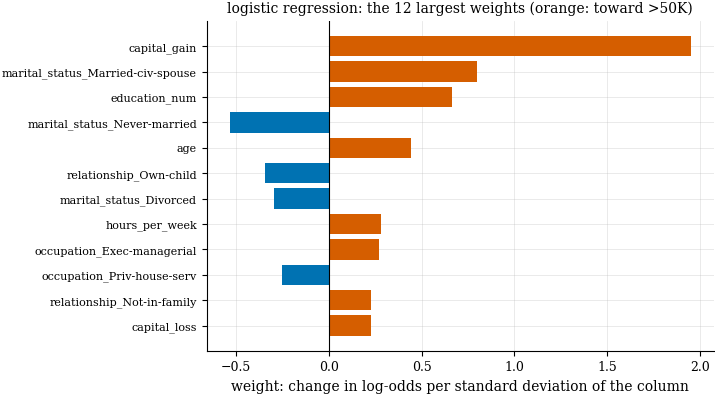

correlation between logistic-regression and linear-SVM weights: 0.996
the RBF SVM has no weights to show: it keeps 1,887 of the 5,000 training people as support vectors


In [35]:
svm_final = contenders["linear SVM"][0]
weights = pd.Series(lr_final.coef_[0], index=prep.names())
top = weights.reindex(weights.abs().sort_values(ascending=False).index[:12])[::-1]

fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.barh(top.index, top.values, color=[C1 if v > 0 else C0 for v in top.values])
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("weight: change in log-odds per standard deviation of the column")
ax.set_title("logistic regression: the 12 largest weights (orange: toward >50K)", fontsize=10)
ax.tick_params(axis="y", labelsize=8)
plt.show()
print(f"correlation between logistic-regression and linear-SVM weights: "
      f"{np.corrcoef(lr_final.coef_[0], svm_final.coef_[0])[0, 1]:.3f}")
print(f"the RBF SVM has no weights to show: it keeps {contenders['RBF SVM'][0].n_support_.sum():,} "
      f"of the {N_TRAIN:,} training people as support vectors")

* **Logistic regression** gives one number per column, and the columns are standardized, so the
  numbers are comparable: capital gain, being married and years of education push hardest toward
  "&gt;50K", never having married hardest away from it.
* **The linear SVM** learned almost the same weights, a reminder that the hinge loss and the
  logistic loss usually agree on the direction and differ mostly in what they say about
  probabilities.
* **The tree** (&sect;6) gives rules, readable at the top and unwieldy below.
* **Naive Bayes** gives per-column evidence tables (&sect;8b), easy to read one at a time but
  double counted.
* **The RBF SVM** gives no compact explanation at all.

### 8d. What if we had more data?

Back to the choice of &sect;2: train every model on samples of increasing size, from 100 rows to all
32,561, and score the test file. At every size each model's knob is **re-tuned** by 3-fold
cross-validation on that sample, because the best setting for 100 rows is not the best for 32,561.
Small sizes are repeated with different samples. One more curve joins in: logistic regression with
the penalty switched off (`C` = 10<sup>6</sup>), for a reason explained below. The RBF SVM stays out:
its cost grows faster than the data (&sect;5), and at the largest sizes it would dominate the run.
**This cell takes a minute or two.**

In [36]:
SIZES = [100, 300, 1_000, 3_000, 10_000, len(X_pool)]
REPEATS = {100: 5, 300: 5, 1_000: 5, 3_000: 3, 10_000: 2, len(X_pool): 1}   # all rows: only one sample
TUNE = {"logistic regression": ([0.01, 0.1, 1], lambda v: LogisticRegression(C=v, max_iter=1000), False),
        "naive Bayes": ([5, 10, 20, 40], lambda v: BinnedNaiveBayes(n_bins=v), True),
        "linear SVM": ([1e-3, 1e-2, 0.1], lambda v: LinearSVC(C=v, dual=False), False),
        "decision tree": ([5, 20, 50, 100, 200],
                          lambda v: DecisionTreeClassifier(min_samples_leaf=v, random_state=SEED), False)}


def fit_on_sample(name, X_s, y_s):
    "re-tune the knob by 3-fold CV on this sample, refit, and return test scores"
    values, make, table = TUNE[name]
    splits = list(StratifiedKFold(3, shuffle=True, random_state=SEED).split(X_s, y_s))
    scale = name != "decision tree"
    best = max(values, key=lambda v: cv_by_hand(lambda: make(v), scale=scale, table=table,
                                                       X=X_s, y=y_s, splits=splits)["auc"])
    if table:
        return score_of(make(best).fit(X_s, y_s), X_test)[0]
    p = TablePrep(scale=scale).fit(X_s)
    return score_of(make(best).fit(p.transform(X_s), y_s), p.transform(X_test))[0]


t0 = time.perf_counter()
curve = []
for n in SIZES:
    for r in range(REPEATS[n]):
        if n < len(X_pool):
            X_s, _, y_s, _ = train_test_split(X_pool, y_pool, train_size=n, stratify=y_pool,
                                              random_state=SEED + 100 + r)
        else:
            X_s, y_s = X_pool, y_pool
        scores = {name: fit_on_sample(name, X_s, y_s) for name in TUNE}
        p_s = TablePrep().fit(X_s)
        with warnings.catch_warnings():     # without a penalty the weights may grow without bound
            warnings.simplefilter("ignore", ConvergenceWarning)
            scores["logistic regression, no penalty"] = LogisticRegression(C=1e6, max_iter=5000).fit(
                p_s.transform(X_s), y_s).predict_proba(p_s.transform(X_test))[:, 1]
        if n == len(X_pool):
            full_scores = scores            # kept for the next cell
        for name, s in scores.items():
            cut = 0.0 if name == "linear SVM" else 0.5
            curve.append({"n": n, "model": name, "AUC": roc_auc_score(y_test, s),
                          "accuracy": np.mean((s > cut) == y_test)})
curve = pd.DataFrame(curve)
print(f"learning curves computed in {time.perf_counter() - t0:.0f} s\n")
for metric in ["AUC", "accuracy"]:
    print(f"test {metric} (mean over the repeats) by number of training rows:")
    print(curve.pivot_table(index="model", columns="n", values=metric).round(3).to_string(), "\n")

learning curves computed in 49 s

test AUC (mean over the repeats) by number of training rows:
n                                100    300    1000   3000   10000  32561
model                                                                    
decision tree                    0.804  0.829  0.856  0.884  0.898  0.905
linear SVM                       0.856  0.874  0.892  0.900  0.903  0.905
logistic regression              0.851  0.871  0.890  0.899  0.902  0.904
logistic regression, no penalty  0.819  0.849  0.881  0.899  0.902  0.904
naive Bayes                      0.860  0.887  0.895  0.898  0.901  0.902 

test accuracy (mean over the repeats) by number of training rows:
n                                100    300    1000   3000   10000  32561
model                                                                    
decision tree                    0.792  0.814  0.819  0.840  0.851  0.860
linear SVM                       0.787  0.813  0.845  0.849  0.853  0.854
logistic regression    

The same numbers as two pictures: test AUC (left) and test accuracy at each model's default cut
(right), against the number of training rows on a log scale. Each point is the mean over the
repeated samples, with error bars of &plusmn;1 standard deviation; the largest size has a single
sample and so no bar. The dashed curve is the logistic regression without a penalty, and the dotted
vertical line marks the development sample of &sect;2&ndash;&sect;7.

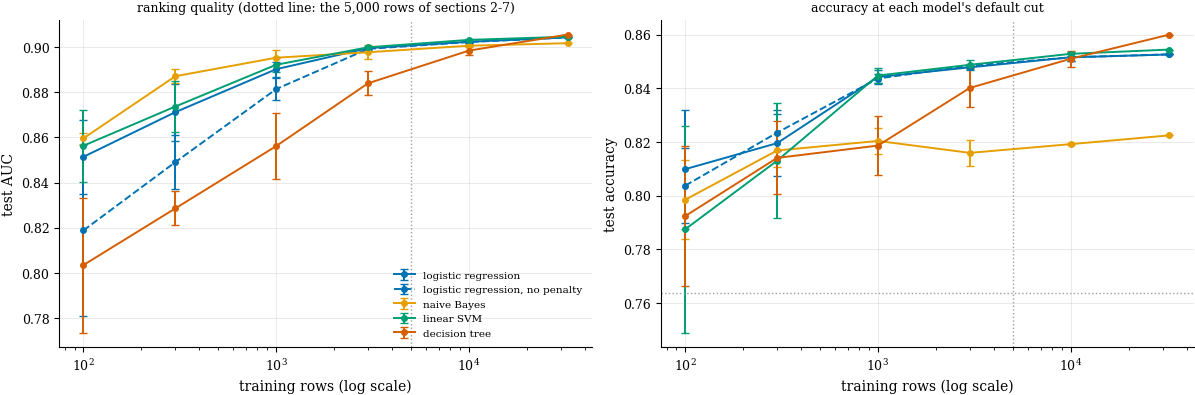

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.0))
styles = dict(COLORS, **{"logistic regression, no penalty": C0})
for ax, metric in zip(axes, ["AUC", "accuracy"]):
    for name in ["logistic regression", "logistic regression, no penalty", "naive Bayes", "linear SVM",
                 "decision tree"]:
        m = curve[curve.model == name].groupby("n")[metric].agg(["mean", "std"])
        ls = "--" if "no penalty" in name else "-"
        ax.errorbar(m.index, m["mean"], yerr=m["std"].fillna(0), fmt="o" + ls, ms=4, lw=1.4, capsize=3,
                    color=styles[name], ecolor=styles[name], label=name)
    ax.set_xscale("log")
    ax.set_xlabel("training rows (log scale)")
    ax.set_ylabel(f"test {metric}")
    ax.axvline(N_TRAIN, color=CX, ls=":", lw=1)
axes[1].axhline(1 - y_test.mean(), color=CX, ls=":", lw=1)
axes[0].legend(fontsize=7.5, loc="lower right")
axes[0].set_title(f"ranking quality (dotted line: the {N_TRAIN:,} rows of sections 2-7)", fontsize=9)
axes[1].set_title("accuracy at each model's default cut", fontsize=9)
plt.show()

Three readings, from left to right.

1. **With little data the generative model is at least as good.** At 300 rows naive Bayes ranks
   clearly best (AUC 0.887, against 0.871 for logistic regression and 0.874 for the linear SVM);
   at 100 and 1,000 rows it is level with the linear SVM, within our 0.005 band. From 3,000 rows
   on the linear models edge ahead, by less than the band. This is the effect Ng &amp; Jordan (2002)
   made famous: a generative model reaches its (lower) ceiling with fewer examples. They compared it
   with logistic regression *without* a penalty, and so does the dashed line: 0.819 against naive
   Bayes's 0.860 with 100 rows, a gap far outside the band. Regularization (Session 03) closes most
   of it.
2. **More data favors the flexible model.** The tree is the worst ranker up to 10,000 rows, but it
   keeps improving after the linear models have flattened out. With all 32,561 rows it is level
   with them in AUC and ahead in accuracy, in the one sample that size allows.
3. **The linear models flatten early.** From 10,000 rows on they gain about 0.002 AUC: they have
   learned what a linear boundary can learn. And naive Bayes's accuracy stays near 0.82 from 300
   rows on, because more data does not cure double counting.

Is the tree's lead with all the rows real? The same paired bootstrap as in &sect;7:

In [38]:
default_cut = {"logistic regression": 0.5, "naive Bayes": 0.5, "linear SVM": 0.0, "decision tree": 0.5}
hits = {n: (full_scores[n] > default_cut[n]) == y_test for n in default_cut}
boot_full = {n: np.array([auc_fast(y_test[i], full_scores[n][i]) for i in redraws])
             for n in ["logistic regression", "linear SVM", "decision tree"]}
print(f"all {len(X_pool):,} training rows (one sample), decision tree minus ..., on the test file:")
for other in ["logistic regression", "linear SVM"]:
    d_auc = boot_full["decision tree"] - boot_full[other]
    d_acc = 100 * (hits["decision tree"][redraws].mean(axis=1) - hits[other][redraws].mean(axis=1))
    print(f"  ... {other:20s} AUC {d_auc.mean():+.4f} [{np.percentile(d_auc, 2.5):+.4f}, "
          f"{np.percentile(d_auc, 97.5):+.4f}]   accuracy {d_acc.mean():+.2f} points "
          f"[{np.percentile(d_acc, 2.5):+.2f}, {np.percentile(d_acc, 97.5):+.2f}]")

complete = ~(test_raw[["workclass", "occupation", "native_country"]].isna().any(axis=1)).to_numpy()
print(f"\nerror on the {complete.sum():,} test rows without a '?', trained on all rows (default cuts):")
print("  " + "   ".join(f"{n} {1 - hits[n][complete].mean():.2%}" for n in hits))

all 32,561 training rows (one sample), decision tree minus ..., on the test file:
  ... logistic regression  AUC +0.0013 [-0.0020, +0.0046]   accuracy +0.75 points [+0.31, +1.17]
  ... linear SVM           AUC +0.0010 [-0.0023, +0.0042]   accuracy +0.56 points [+0.14, +0.98]

error on the 15,060 test rows without a '?', trained on all rows (default cuts):
  logistic regression 15.25%   naive Bayes 18.54%   linear SVM 15.05%   decision tree 14.48%


In AUC there is no detectable difference between the tree and either linear model: both intervals
include zero. In accuracy the tree is ahead of both (by 0.75 and 0.56 points), with intervals that
clear zero but straddle our 0.5-point band. And this is a single training sample, so only test-file
luck has been checked. So &sect;2's question gets a cautious answer: **with all the rows, the order of
the models changes.** The model that came last with 5,000 rows now ranks people as well as the
others, and may be slightly ahead in accuracy: a strong hint, not yet a verdict.

For a sense of scale: the dataset's own documentation (1996) lists the test error of several
algorithms run with default settings on the 30,162 complete training rows and scored on the 15,060
complete test rows. Among them are **C4.5** (a decision tree) at 15.54%, **naive Bayes** at 16.12%,
and the best entry, a naive Bayes with feature selection, at 14.05%. The last line above scores our
models on those same 15,060 test rows. The setups differ (we also train on the incomplete rows, and
we tune), so treat the comparison as indicative only. Our tree, linear SVM and logistic regression
(14.48% to 15.25%) land in the same range as the 1996 results; our naive Bayes does worse at its
default cut (18.54%), because its overconfident probabilities put that cut in the wrong place
(&sect;8a). Whether any method can go clearly further on this table is a question for the ensemble
methods of Session 09.

## 9. Which one would you deploy?

> &#11088; **Key idea.** For this use case, with about 5,000 labeled people: **logistic regression.**
> It ranks people as well as any contender (test AUC 0.901, tied with naive Bayes and the linear
> SVM in every check above). Its probabilities are honest (ECE 0.005), so its default cut is
> already the right one (accuracy 0.850 with either cut). It trains and predicts in milliseconds,
> and its weights can be read (&sect;8c).

The runners-up, and what each would cost you:

* **Linear SVM.** The same ranking and almost the same weights (correlation 0.996), but no
  probabilities until you add Platt scaling.
* **Naive Bayes.** The same ranking with 5,000 rows, and at least as good as any with a few hundred.
  But it is overconfident: its cut must be re-chosen, and its probabilities cannot be used as they
  are.
* **RBF SVM.** Slightly worse here, and scoring the test file takes it seconds instead of
  milliseconds.
* **Decision tree.** Behind with 5,000 rows (&minus;0.007 AUC), but the most readable. With all
  32,561 rows it ranks as well as the linear models and may be slightly ahead in accuracy.

What would change the answer, according to this notebook's own measurements:

| if &hellip; | then prefer &hellip; | evidence |
|---|---|---|
| you have only a few hundred labeled rows | naive Bayes for ranking | &sect;8d |
| you have tens of thousands of rows | re-run the comparison: the tree catches up (level in AUC, half to three quarters of a point ahead in accuracy in our one full-size sample) | &sect;8d |
| a person must be able to audit the decisions as rules | a depth-3 tree: 8 rules, as accurate at its cut, but a coarse ranking (validation AUC 0.851) | &sect;6 |
| the probabilities feed another calculation | logistic regression, or an SVM with Platt scaling | &sect;8a |
| predictions must be cheap at scale | any linear model, not the RBF SVM | &sect;5, &sect;7 |

The whole comparison in one table, cross-validation on the left, the test file on the right:

In [39]:
cv_board = pd.DataFrame(board).set_index("model")[["CV AUC", "AUC sd", "setting"]]
verdict = cv_board.join(final[["test AUC", "accuracy, chosen cut", "log loss", "fit s", "predict s"]])
print(f"whole notebook: {time.perf_counter() - T_START:.0f} s")
verdict.round(3)

whole notebook: 123 s


,CV AUC,AUC sd,setting,test AUC,"accuracy, chosen cut",log loss,fit s,predict s
model,,,,,,,,
always '<=50K',0.500,0.000,-,0.500,0.764,NaN,NaN,NaN
logistic regression,0.899,0.010,C=0.3,0.901,0.850,0.324,0.022,0.004
naive Bayes,0.895,0.012,80 bins,0.902,0.849,0.416,0.025,0.050
linear SVM,0.899,0.009,C=0.1,0.901,0.852,NaN,0.053,0.002
RBF SVM,0.894,0.008,"C=10, gamma=0.001",0.898,0.847,NaN,0.664,5.011
decision tree,0.887,0.011,min_samples_leaf=50,0.894,0.843,0.435,0.015,0.004


## Recap & exercises

**Recap.**

* **Real data needs checking before modeling.** The test labels end with a period (an exact match
  finds 0 high earners), `fnlwgt` is a sampling weight with no signal (AUC 0.493), `education`
  duplicates `education_num`, and the incomplete rows earn less than the rest (13.9% against
  24.9%), so "missing" became a category instead of a reason to drop rows.
* **Preprocessing is learned, so it belongs inside the split.** Encoding the files separately gives
  84 and 85 columns; `TablePrep` learns categories and scales from training rows only, and the
  cross-validation loop refits it in every fold.
* **Logistic regression:** `C` barely matters once it is not tiny; the strongest penalty still ranks
  (AUC 0.872) but answers "&le;50K" for everyone.
* **Naive Bayes** is only as good as its likelihood: Gaussians on 0/1 columns give accuracy 0.548,
  frequency tables with binned numbers give AUC 0.895. Writing its sum out by hand also shows how a
  generative model handles a value it has never seen: it leaves that column out.
* **SVMs:** the best RBF setting has the widest kernel and still trails the linear SVM in all five
  folds, while costing much more to train and to use.
* **Decision tree:** a fully grown tree memorizes (training AUC 1.000, validation 0.732);
  `min_samples_leaf` = 50 is the sweet spot, the top rules read like common sense, and scaling
  changes nothing.
* **On the test file**, logistic regression, naive Bayes and the linear SVM tie (AUC 0.901 to 0.902); only
  the tree's deficit is both reliable and large enough to matter, and only just.
* **Beyond the score:** naive Bayes is overconfident, partly because it counts the same fact up to
  three times (odds &times;416 against &times;16); dropping the redundant columns halves its
  calibration error without touching its AUC. More data changes the order of the models at both
  ends: with a few hundred rows naive Bayes ranks at least as well as anything else, and with all
  32,561 the tree catches up.

**Exercises** (roughly in order of effort).

1. Change `SEED`, or set `N_TRAIN` to 2,000 and then to 10,000, and run everything again. Which
   conclusions of &sect;3&ndash;&sect;7 survive?
2. Add `class_weight="balanced"` to the logistic regression. What happens to the AUC, to the
   accuracy at the default cut, and to the cut chosen on the out-of-fold scores? Why does the AUC
   hardly move?
3. Replace `capital_gain` and `capital_loss` by `np.log1p` of themselves inside `TablePrep`. Does
   it help logistic regression? Plot the share of high earners against capital gain to explain what
   you see.
4. Extend the RBF grid of &sect;5 toward smaller $\gamma$ and larger `C` (the best point sat on the
   edge). Does the RBF SVM catch up with the linear one? Does it overtake it?
5. Hunt for the rest of naive Bayes's overconfidence: drop further columns that overlap with others
   (try `education_num`, `occupation`, `age`) and follow the ECE and the AUC. How low can the ECE
   go before the AUC starts to fall?
6. Add LDA (Lecture 05) as a second generative model, on the scaled matrix. Is it closer to naive
   Bayes or to logistic regression, in AUC and in calibration?
7. For the recommended model, compute the recall and the false positive rate separately for women
   and for men on the test file. What does a single accuracy number hide? (Keep in mind that the two
   groups have very different shares of high earners.)
8. *Stretch.* Run the same comparison on another UCI table, for example *Online Shoppers Purchasing
   Intention* (id 468) or *Predict Students' Dropout and Academic Success* (id 697). Is the order
   of the models the same?

*Data:* B. Becker and R. Kohavi, *Adult*, UCI Machine Learning Repository, 1996,
doi:10.24432/C5XW20 (CC BY 4.0). *References:* A. Y. Ng and M. I. Jordan, "On discriminative vs.
generative classifiers: a comparison of logistic regression and naive Bayes", *Advances in Neural
Information Processing Systems* 14, 2002; S. S. Keerthi and C.-J. Lin, "Asymptotic behaviors of
support vector machines with Gaussian kernel", *Neural Computation* 15(7), 2003; J. Platt,
"Probabilistic outputs for support vector machines and comparisons to regularized likelihood
methods", in *Advances in Large Margin Classifiers*, MIT Press, 1999.